In [ ]:
import re
import numpy as np
import pandas as pd

from dataclasses import dataclass

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score, average_precision_score, f1_score,
    confusion_matrix, classification_report, precision_recall_curve
)

from sklearn.inspection import permutation_importance, PartialDependenceDisplay

import matplotlib.pyplot as plt

RANDOM_STATE = 42
pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 160)

In [ ]:
cards_path = "/content/ДТП_карточки_21-26.csv"
parts_path = "/content/ДТП_участники_21-26.csv"

cards = pd.read_csv(cards_path, sep=";", encoding="utf-8-sig")
parts = pd.read_csv(parts_path, sep=";", encoding="utf-8-sig")

cards.columns = cards.columns.str.strip()
parts.columns = parts.columns.str.strip()

cards["Номер ДТП"] = cards["Номер ДТП"].astype(str).str.strip()
parts["Номер_ДТП"] = parts["Номер_ДТП"].astype(str).str.strip()

print("Loaded:")
print(" cards:", cards.shape)
print(" parts:", parts.shape)

cards.head(2)

Loaded:
 cards: (1735, 25)
 parts: (3481, 11)


,Номер,Дата,Время,Схема,Широта,Долгота,Номер ДТП,Вид ДТП,Адрес,Дорога,Значение дороги,Категория дороги,Категория улицы,Объекты УДС на месте ДТП,Объекты УДС вблизи места ДТП,"Нарушения обязательных требований к эксплуатационному состоянию и обустройству автомобильных дорог общего пользования, улиц и дорог городов и сельских поселений, железнодорожных переездов","Факторы, оказывающие влияние на режим движения",Состояние погоды,Состояние проезжей части,Освещение,Изменения в режиме движения,Количество ТС,Число участников,Число погибших,Число раненых
0,1.0,30.09.2025,12:27,610.0,51.506071,92.950687,930002158.0,Опрокидывание,Улуг-Хемский район,NaN,"Местного значения (дорога местного значения, в...",NaN,Вне НП,Отсутствие в непосредственной близости объекто...,Перегон (нет объектов на месте ДТП),Не установлены,Сведения отсутствуют,Пасмурно,Сухое,Светлое время суток,Режим движения не изменялся,1.0,1.0,0.0,1.0
1,NaN,NaN,NaN,NaN,NaN,NaN,nan,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Формирование целевой переменной и временных признаков

In [ ]:

cards["fatal"] = (pd.to_numeric(cards["Число погибших"], errors="coerce").fillna(0) >= 1).astype(int)
base_fatal_rate = float(cards["fatal"].mean())

cards["Дата"] = pd.to_datetime(cards["Дата"], errors="coerce", dayfirst=True)
cards = cards.dropna(subset=["Дата"]).copy()

cards["year"] = cards["Дата"].dt.year
cards["month"] = cards["Дата"].dt.month
cards["dow"] = cards["Дата"].dt.dayofweek
cards["is_weekend"] = cards["dow"].isin([5, 6]).astype(int)

cards["Время"] = cards["Время"].astype(str).str.strip()
cards["hour"] = pd.to_numeric(cards["Время"].str.slice(0, 2), errors="coerce")

print("Target distribution:")
print(cards["fatal"].value_counts())
print("fatal rate:", round(base_fatal_rate, 4))

print("\nDate range:", cards["Дата"].min(), "→", cards["Дата"].max())
cards[["Номер ДТП","Дата","hour","fatal"]].head(5)

Target distribution:
fatal
0    1465
1     269
Name: count, dtype: int64
fatal rate: 0.155

Date range: 2021-01-01 00:00:00 → 2026-01-31 00:00:00


,Номер ДТП,Дата,hour,fatal
0,930002158.0,2025-09-30,12,0
2,930002156.0,2025-09-30,12,0
3,930002159.0,2025-09-30,13,0
4,930002148.0,2025-09-29,19,0
5,930002151.0,2025-09-29,20,1


## Разбиение данных по времени

In [ ]:

cards = cards.sort_values("Дата").reset_index(drop=True)

cards["ym"] = cards["Дата"].dt.to_period("M")

VAL_START  = pd.Period("2025-03", freq="M")
TEST_START = pd.Period("2025-09", freq="M")

train_mask = cards["ym"] < VAL_START
val_mask   = (cards["ym"] >= VAL_START) & (cards["ym"] < TEST_START)
test_mask  = cards["ym"] >= TEST_START

print("Split sizes:")
print(" train:", int(train_mask.sum()))
print("   val:", int(val_mask.sum()))
print("  test:", int(test_mask.sum()))

print("\nLast months counts:")
print(cards["ym"].value_counts().sort_index().tail(12))

Split sizes:
 train: 1184
   val: 358
  test: 192

Last months counts:
ym
2025-02    27
2025-03    45
2025-04    61
2025-05    59
2025-06    57
2025-07    79
2025-08    57
2025-09    53
2025-10    49
2025-11    32
2025-12    34
2026-01    24
Freq: M, Name: count, dtype: int64


## Подбор порога и расчёт метрик

In [ ]:

def find_best_threshold_f1(y_true, proba):
    precision, recall, thr = precision_recall_curve(y_true, proba)
    thr_full = np.concatenate([thr, [1.0]])
    f1 = 2 * precision * recall / (precision + recall + 1e-12)
    best_idx = int(np.nanargmax(f1))
    return float(thr_full[best_idx]), float(f1[best_idx]), float(precision[best_idx]), float(recall[best_idx])

def eval_at_threshold(y_true, proba, thr, label=""):
    pred = (proba >= thr).astype(int)
    out = {
        "roc_auc": float(roc_auc_score(y_true, proba)),
        "pr_auc": float(average_precision_score(y_true, proba)),
        "f1": float(f1_score(y_true, pred)),
        "thr": float(thr),
    }
    print(f"\n[{label}] ROC-AUC={out['roc_auc']:.4f} | PR-AUC={out['pr_auc']:.4f} | F1={out['f1']:.4f} | thr={out['thr']:.4f}")
    print("Confusion:\n", confusion_matrix(y_true, pred))
    print(classification_report(y_true, pred, digits=3))
    return out

def plot_pr_curve(y_true, proba, title="PR curve"):
    prec, rec, _ = precision_recall_curve(y_true, proba)
    plt.figure(figsize=(7,5))
    plt.plot(rec, prec)
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(title)
    plt.grid(True)
    plt.show()

## Мульти-хот кодирование

In [ ]:

@dataclass
class MultiHotSpec:
    col: str
    prefix: str
    min_freq: int = 10
    drop_values: tuple = ("Сведения отсутствуют", "Не установлены")

class MultiHotPipeFeaturizer:
    def __init__(self, specs):
        self.specs = specs
        self.keep_tokens_ = {}
        self.columns_ = []

    @staticmethod
    def _norm_series(s: pd.Series, drop_values):
        s = (
            s.fillna("").astype(str)
             .str.replace(r"\s*\|\s*", "|", regex=True)
             .str.strip()
        )
        drop_set = set(v.lower() for v in drop_values)
        s = s.apply(lambda x: "" if x.lower() in drop_set else x)
        return s

    def fit(self, df_train: pd.DataFrame):
        all_cols = []
        for sp in self.specs:
            if sp.col not in df_train.columns:
                self.keep_tokens_[sp.col] = set()
                continue

            s = self._norm_series(df_train[sp.col], sp.drop_values)
            exploded = (
                s.replace("", np.nan).dropna()
                 .str.split("|").explode().str.strip()
            )
            if exploded.empty:
                self.keep_tokens_[sp.col] = set()
                continue

            vc = exploded.value_counts()
            keep = set(vc[vc >= sp.min_freq].index.tolist())
            self.keep_tokens_[sp.col] = keep

            for tok in sorted(list(keep)):
                all_cols.append(f"{sp.prefix}_{tok}")
            all_cols.append(f"{sp.prefix}___OTHER__")

        self.columns_ = list(dict.fromkeys(all_cols))
        return self

    def transform(self, df: pd.DataFrame) -> pd.DataFrame:
        out_blocks = []
        for sp in self.specs:
            if sp.col not in df.columns:
                out_blocks.append(pd.DataFrame(0, index=df.index, columns=[]))
                continue

            keep = self.keep_tokens_.get(sp.col, set())
            s = self._norm_series(df[sp.col], sp.drop_values)

            def map_tokens(x):
                if not x:
                    return []
                toks = [t.strip() for t in str(x).split("|")]
                toks = [t for t in toks if t]
                mapped = [(t if t in keep else "__OTHER__") for t in toks]
                return mapped

            s2 = s.apply(map_tokens)
            tmp = s2.explode()
            if tmp.dropna().empty:
                out_blocks.append(pd.DataFrame(0, index=df.index, columns=[]))
                continue

            d = pd.get_dummies(tmp, prefix=sp.prefix)
            d = d.groupby(level=0).max().reindex(df.index, fill_value=0).astype(int)

            other_col = f"{sp.prefix}___OTHER__"
            if other_col not in d.columns:
                d[other_col] = 0

            out_blocks.append(d)

        res = pd.concat(out_blocks, axis=1) if out_blocks else pd.DataFrame(index=df.index)

        for c in self.columns_:
            if c not in res.columns:
                res[c] = 0
        res = res[self.columns_].astype(int)

        return res

## Построение агрегированных признаков(n_vehicles, агрегаты возраста авто, наличие типов ТС, доли/наличие групп цвета (light/dark/bright/other))

In [ ]:

def compute_vehicle_type(series: pd.Series) -> pd.Series:
    t = series.fillna("").astype(str).str.strip().str.lower()

    motor   = t.str.contains("мотоцикл|мопед|квадроцикл", regex=True)
    bicycle = t.str.contains("велосипед", regex=True)
    bus     = t.str.contains("автобус", regex=True)
    truck   = t.str.contains("грузовой|бортов|самосвал|тягач|цистерн|фургон|рефриж|полуприцеп", regex=True)
    special = t.str.contains("трактор|автогрейдер|снегоход|спецтех|коммунальн|медицинск|аварийн|спасат|полици", regex=True)
    car     = t.str.contains("класс|минивэн|универсал|легков|прочие легковые|седан|хэтчбек|кроссовер|внедорож", regex=True)

    vt = np.select(
        [motor, bicycle, bus, truck, special, car, t.ne("")],
        ["motorcycle", "bicycle", "bus", "truck", "special", "car", "other"],
        default="unknown"
    )
    return pd.Series(vt, index=series.index)

def map_color_group(x) -> str:
    """
    Map raw color string to {light, dark, bright, other}.
    Uses substring rules (robust to 'серебристый', 'темно-синий', etc.).
    """
    s = str(x).lower().strip()
    if s in ("", "nan", "none"):
        return "other"

    light = ("бел", "сер", "сереб", "беж", "крем", "слон")
    dark = ("черн", "син", "корич", "тёмно", "темно", "бордов", "марун", "графит")
    bright = ("крас", "желт", "жёлт", "зел", "оранж", "фиол", "роз", "голуб", "бирюз")

    if any(tok in s for tok in light):
        return "light"
    if any(tok in s for tok in dark):
        return "dark"
    if any(tok in s for tok in bright):
        return "bright"
    return "other"

def build_parts_agg(parts_df: pd.DataFrame, cards_df: pd.DataFrame):

    parts_df = parts_df.copy()

    parts_df["Год_выпуска"] = pd.to_numeric(parts_df["Год_выпуска"], errors="coerce")

    cards_year = cards_df[["Номер ДТП", "year"]].copy()
    parts_df = parts_df.merge(cards_year, left_on="Номер_ДТП", right_on="Номер ДТП", how="left")

    parts_df["car_age"] = parts_df["year"] - parts_df["Год_выпуска"]
    parts_df.loc[(parts_df["car_age"] < 0) | (parts_df["car_age"] > 60), "car_age"] = np.nan

    parts_df["vehicle_type"] = compute_vehicle_type(parts_df["Тип_ТС"])
    veh_dum = pd.get_dummies(parts_df["vehicle_type"], prefix="veh")

    expected_veh = [
        "veh_motorcycle", "veh_bicycle", "veh_bus", "veh_truck",
        "veh_special", "veh_car", "veh_other", "veh_unknown"
    ]
    for c in expected_veh:
        if c not in veh_dum.columns:
            veh_dum[c] = 0
    parts_df = pd.concat([parts_df, veh_dum[expected_veh]], axis=1)

    parts_df["color_grp"] = parts_df["Цвет"].apply(map_color_group)
    col_dum = pd.get_dummies(parts_df["color_grp"], prefix="col")

    for c in ["col_light", "col_dark", "col_bright", "col_other"]:
        if c not in col_dum.columns:
            col_dum[c] = 0

    parts_df = pd.concat([parts_df, col_dum[["col_light", "col_dark", "col_bright", "col_other"]]], axis=1)

    def nanmean_bool(cond: pd.Series) -> float:
        arr = cond.astype(float).to_numpy()
        return np.nanmean(arr) if np.isfinite(arr).any() else np.nan

    parts_agg = parts_df.groupby("Номер_ДТП").agg(
    n_vehicles=("Номер_ТС", "nunique"),

    mean_car_age=("car_age", "mean"),
    share_old20=("car_age", lambda x: nanmean_bool(x >= 20)),

    has_motorcycle=("veh_motorcycle", "max"),
    has_truck=("veh_truck", "max"),
    has_bus=("veh_bus", "max"),
    has_bicycle=("veh_bicycle", "max"),
    has_special=("veh_special", "max"),
    has_car=("veh_car", "max"),
).reset_index()

    color_cols = ["col_light", "col_dark", "col_bright", "col_other"]
    color_sum = parts_df.groupby("Номер_ДТП")[color_cols].sum().reset_index()
    color_sum = color_sum.merge(parts_agg[["Номер_ДТП", "n_vehicles"]], on="Номер_ДТП", how="left")

    for c in color_cols:
        share_name = c.replace("col_", "share_col_")
        has_name   = c.replace("col_", "has_col_")
        color_sum[share_name] = np.where(color_sum["n_vehicles"] > 0, color_sum[c] / color_sum["n_vehicles"], np.nan)
        color_sum[has_name] = (color_sum[c] > 0).astype(int)

    keep_color = [c for c in color_sum.columns
              if c.startswith("has_col_")]
    parts_agg = parts_agg.merge(color_sum[["Номер_ДТП"] + keep_color], on="Номер_ДТП", how="left")

    return parts_agg

In [ ]:

multi_specs = []

mh = MultiHotPipeFeaturizer(multi_specs)
mh.fit(cards.loc[train_mask].copy())
mh_train_cols = len(mh.columns_)
print("Multi-hot fitted columns:", mh_train_cols)

mh_all = mh.transform(cards)

parts_agg = build_parts_agg(parts, cards)
print("parts_agg:", parts_agg.shape)

df = cards.copy()
df = pd.concat([df.reset_index(drop=True), mh_all.reset_index(drop=True)], axis=1)

df = df.merge(parts_agg, left_on="Номер ДТП", right_on="Номер_ДТП", how="left")


zero_fill_cols = [c for c in df.columns if c.startswith("has_") or c.startswith("n_")]
df[zero_fill_cols] = df[zero_fill_cols].fillna(0)

color_has_cols = [c for c in df.columns if c.startswith("has_col_")]
df[color_has_cols] = df[color_has_cols].fillna(0)

has_cols = [c for c in df.columns if c.startswith("has_")]
df[has_cols] = df[has_cols].fillna(0).astype(int)

print("Final df:", df.shape)
df[["Номер ДТП","Дата","fatal","hour","month","dow","is_weekend","n_vehicles"]].head(5)

Multi-hot fitted columns: 0
parts_agg: (1734, 14)
Final df: (1734, 46)


,Номер ДТП,Дата,fatal,hour,month,dow,is_weekend,n_vehicles
0,930000008.0,2021-01-01,1,22,1,4,0,1
1,930000019.0,2021-01-03,0,23,1,6,1,2
2,930000018.0,2021-01-03,1,16,1,6,1,2
3,930000020.0,2021-01-04,1,9,1,0,0,2
4,930000054.0,2021-01-11,0,10,1,0,0,1


## Предобработка и очистка


In [ ]:

DROP_COLS = [
    "Число погибших", "Число раненых",
    "Номер", "Адрес", "Дорога", "Схема",
    "Изменения в режиме движения",
    "Категория дороги",
    "Время",
]

df = df.drop(columns=[c for c in DROP_COLS if c in df.columns], errors="ignore")

print("df columns:", len(df.columns))


if "Категория улицы" in df.columns:
    s = df["Категория улицы"].astype(str).str.strip()

    df["is_outside_np"] = (s == "Вне НП").astype(int)

    s2 = s.replace({"Вне НП": "UNKNOWN"})
    s2 = s2.replace({"nan": "UNKNOWN", "": "UNKNOWN"})

    MIN_FREQ = 30
    vc = s2.value_counts()
    keep = set(vc[vc >= MIN_FREQ].index)

    df["street_cat_simpl"] = s2.where(s2.isin(keep), other="OTHER").astype(str)

    df = df.drop(columns=["Категория улицы"])

df columns: 37


## Формирование наборов признаков: STRICT и EXTENDED

In [ ]:
y = df["fatal"].astype(int)

strict_card_cols = [
    "Вид ДТП",
    "Значение дороги",
    "Состояние проезжей части",
    "Освещение",
    "Состояние погоды",
    "hour", "month", "dow", "is_weekend",
    "is_outside_np",
]

strict_card_cols = [c for c in strict_card_cols if c in df.columns]
mh_cols = mh.columns_[:] if "mh" in globals() else []
mh_cols = [c for c in mh_cols if c in df.columns]
part_cols = []

for c in ["n_vehicles", "mean_car_age", "share_old20"]:
    if c in df.columns:
        part_cols.append(c)

part_cols += [c for c in df.columns if c.startswith("has_")]

part_cols += [c for c in df.columns if c.startswith("has_col_")]

strict_features = strict_card_cols + mh_cols + part_cols

extended_features = strict_features.copy()
for c in ["Количество ТС", "Число участников"]:
    if c in df.columns and c not in extended_features:
        extended_features.append(c)

def _dedup_keep_order(lst):
    seen = set()
    out = []
    for x in lst:
        if x not in seen:
            out.append(x)
            seen.add(x)
    return out

strict_features = _dedup_keep_order([c for c in strict_features if c in df.columns and c != "fatal"])
extended_features = _dedup_keep_order([c for c in extended_features if c in df.columns and c != "fatal"])

print("STRICT features:", len(strict_features))
print("EXTENDED features:", len(extended_features))

print("\n[CHECK] missing in df (should be empty):")
print(" strict missing:", [c for c in strict_features if c not in df.columns])
print("   ext missing:", [c for c in extended_features if c not in df.columns])

print("\nFirst 25 STRICT features:")
print(strict_features[:25])

STRICT features: 23
EXTENDED features: 25

[CHECK] missing in df (should be empty):
 strict missing: []
   ext missing: []

First 25 STRICT features:
['Вид ДТП', 'Значение дороги', 'Состояние проезжей части', 'Освещение', 'Состояние погоды', 'hour', 'month', 'dow', 'is_weekend', 'is_outside_np', 'n_vehicles', 'mean_car_age', 'share_old20', 'has_motorcycle', 'has_truck', 'has_bus', 'has_bicycle', 'has_special', 'has_car', 'has_col_light', 'has_col_dark', 'has_col_bright', 'has_col_other']


In [ ]:
GEO_COLS = ["Широта", "Долгота"]

def drop_geo_from_feature_list(feature_list):
    return [c for c in feature_list if c not in GEO_COLS]

strict_features = drop_geo_from_feature_list(strict_features)
extended_features = drop_geo_from_feature_list(extended_features)

df = df.drop(columns=[c for c in GEO_COLS if c in df.columns])

print("Geo features removed.")
print("STRICT features:", len(strict_features))
print("EXTENDED features:", len(extended_features))

Geo features removed.
STRICT features: 23
EXTENDED features: 25


In [ ]:
assert "df" in globals(), "df is not defined. Run data preparation cells first."
assert "cards" in globals(), "cards is not defined. Run data loading cells first."

assert len(df) == len(cards), f"df length mismatch: len(df)={len(df)} vs len(cards)={len(cards)}. Check merges/reset_index."

if "Дата" not in df.columns:
    raise KeyError("Column 'Дата' not found in df. Ensure you kept it during preprocessing.")

if not pd.api.types.is_datetime64_any_dtype(df["Дата"]):
    df["Дата"] = pd.to_datetime(df["Дата"], errors="coerce", dayfirst=True)

if df["Дата"].isna().any():
    bad = int(df["Дата"].isna().sum())
    raise ValueError(f"'Дата' has {bad} NaT values. Fix date parsing/drop NaT before splitting.")

need_masks = not all(name in globals() for name in ["train_mask", "val_mask", "test_mask"])

if need_masks:
    VAL_START  = pd.Period("2025-03", freq="M")
    TEST_START = pd.Period("2025-09", freq="M")

    ym = df["Дата"].dt.to_period("M")

    train_mask = ym < VAL_START
    val_mask   = (ym >= VAL_START) & (ym < TEST_START)
    test_mask  = ym >= TEST_START

train_idx = df.index[train_mask]
val_idx   = df.index[val_mask]
test_idx  = df.index[test_mask]

print("Index split sizes:")
print(" train:", len(train_idx))
print("   val:", len(val_idx))
print("  test:", len(test_idx))

print("\nDate ranges by split:")
print(" train:", df.loc[train_idx, "Дата"].min(), "→", df.loc[train_idx, "Дата"].max())
print("   val:", df.loc[val_idx,   "Дата"].min(), "→", df.loc[val_idx,   "Дата"].max())
print("  test:", df.loc[test_idx,  "Дата"].min(), "→", df.loc[test_idx,  "Дата"].max())

Index split sizes:
 train: 1184
   val: 358
  test: 192

Date ranges by split:
 train: 2021-01-01 00:00:00 → 2025-02-28 00:00:00
   val: 2025-03-01 00:00:00 → 2025-08-31 00:00:00
  test: 2025-09-01 00:00:00 → 2026-01-31 00:00:00


## Оценка логит-модели


===== LOGIT STRICT =====
Used features: 23 | numeric=18 | cat=5
VAL best_thr=0.6410 | F1=0.3486 | P=0.3455 | R=0.3519


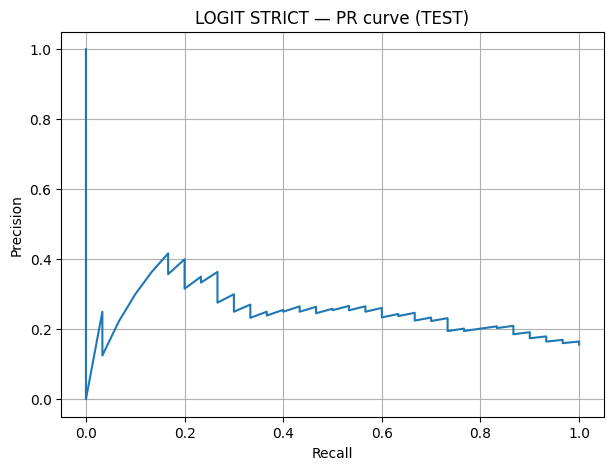


[LOGIT STRICT TEST] ROC-AUC=0.6667 | PR-AUC=0.2602 | F1=0.2778 | thr=0.6410
Confusion:
 [[130  32]
 [ 20  10]]
              precision    recall  f1-score   support

           0      0.867     0.802     0.833       162
           1      0.238     0.333     0.278        30

    accuracy                          0.729       192
   macro avg      0.552     0.568     0.556       192
weighted avg      0.768     0.729     0.747       192


Top 40 |coef| (OR = exp(coef)):
                                                                                                                                                   feature      coef  odds_ratio
                                                                                                    cat__Состояние погоды_Пасмурно | Температура ниже -30С  1.356634    3.883101
                                                                                                                       cat__Вид ДТП_Наезд на велосипедиста  1.099641    3.0030

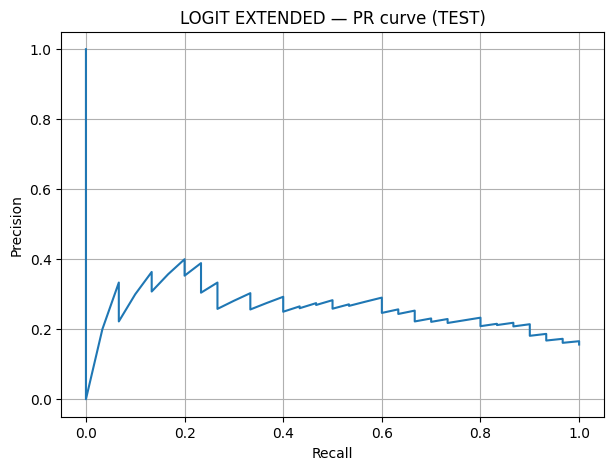


[LOGIT EXTENDED TEST] ROC-AUC=0.6864 | PR-AUC=0.2698 | F1=0.3529 | thr=0.3869
Confusion:
 [[80 82]
 [ 6 24]]
              precision    recall  f1-score   support

           0      0.930     0.494     0.645       162
           1      0.226     0.800     0.353        30

    accuracy                          0.542       192
   macro avg      0.578     0.647     0.499       192
weighted avg      0.820     0.542     0.600       192


Top 40 |coef| (OR = exp(coef)):
                                                                                                                                                   feature      coef  odds_ratio
                                                                                                    cat__Состояние погоды_Пасмурно | Температура ниже -30С  1.299290    3.666692
                                                                                                                       cat__Вид ДТП_Наезд на велосипедиста  1.104202    3.016815

In [ ]:
def run_logit_time_split(features, label, top_n_print=40):
    features = list(features)
    missing = [c for c in features if c not in df.columns]
    if missing:
        print(f"[WARN] {label}: dropping missing features (n={len(missing)}): {missing}")
    use_features = [c for c in features if c in df.columns]

    X = df[use_features].copy()
    y = df["fatal"].astype(int)

    X_train, y_train = X.loc[train_idx], y.loc[train_idx]
    X_val,   y_val   = X.loc[val_idx],   y.loc[val_idx]
    X_test,  y_test  = X.loc[test_idx],  y.loc[test_idx]

    numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
    categorical_cols = [c for c in X.columns if c not in numeric_cols]

    pre = ColumnTransformer(
        transformers=[
            ("num", Pipeline([
                ("imp", SimpleImputer(strategy="median")),
                ("sc", StandardScaler())
            ]), numeric_cols),
            ("cat", Pipeline([
                ("imp", SimpleImputer(strategy="most_frequent")),
                ("ohe", OneHotEncoder(handle_unknown="ignore"))
            ]), categorical_cols),
        ],
        remainder="drop"
    )

    clf = LogisticRegression(max_iter=5000, class_weight="balanced", random_state=RANDOM_STATE)
    pipe = Pipeline([("pre", pre), ("clf", clf)])

    pipe.fit(X_train, y_train)

    proba_val = pipe.predict_proba(X_val)[:, 1]
    best_thr, best_f1, best_prec, best_rec = find_best_threshold_f1(y_val.values, proba_val)

    print(f"\n===== LOGIT {label} =====")
    print(f"Used features: {len(use_features)} | numeric={len(numeric_cols)} | cat={len(categorical_cols)}")
    print(f"VAL best_thr={best_thr:.4f} | F1={best_f1:.4f} | P={best_prec:.4f} | R={best_rec:.4f}")

    proba_test = pipe.predict_proba(X_test)[:, 1]
    plot_pr_curve(y_test.values, proba_test, title=f"LOGIT {label} — PR curve (TEST)")
    metrics = eval_at_threshold(y_test.values, proba_test, best_thr, label=f"LOGIT {label} TEST")

    try:
        feat_names = list(pipe.named_steps["pre"].get_feature_names_out())
    except Exception:
        ohe = pipe.named_steps["pre"].named_transformers_["cat"].named_steps["ohe"]
        cat_names = ohe.get_feature_names_out(categorical_cols) if len(categorical_cols) else np.array([])
        feat_names = np.concatenate([np.array(numeric_cols), cat_names]).tolist()

    coefs = pipe.named_steps["clf"].coef_.ravel()

    if len(feat_names) != len(coefs):
        print(f"[WARN] feature_names mismatch: names={len(feat_names)} vs coefs={len(coefs)}; using generic names.")
        feat_names = [f"f{i}" for i in range(len(coefs))]

    imp = pd.DataFrame({"feature": feat_names, "coef": coefs})
    imp["odds_ratio"] = np.exp(imp["coef"])
    imp["abs_coef"] = np.abs(imp["coef"])
    imp = imp.sort_values("abs_coef", ascending=False)

    print(f"\nTop {top_n_print} |coef| (OR = exp(coef)):")
    print(imp.head(top_n_print)[["feature","coef","odds_ratio"]].to_string(index=False))

    return pipe, metrics, imp, use_features, missing


logit_strict, met_logit_strict, imp_logit_strict, used_strict, miss_strict = run_logit_time_split(
    strict_features, "STRICT", top_n_print=40
)

logit_ext, met_logit_ext, imp_logit_ext, used_ext, miss_ext = run_logit_time_split(
    extended_features, "EXTENDED", top_n_print=40
)

In [ ]:
from sklearn.utils import resample

def bootstrap_logit_coefs_fixed_design(
    preprocessor,
    X_train_raw: pd.DataFrame,
    y_train: pd.Series,
    class_weight="balanced",
    B=300,
    random_state=42,
    max_iter=5000
):

    X_fixed = preprocessor.transform(X_train_raw)
    if hasattr(X_fixed, "toarray"):
        X_fixed = X_fixed.toarray()


    feat_names = list(preprocessor.get_feature_names_out())
    p = X_fixed.shape[1]

    rng = np.random.default_rng(random_state)
    n = X_fixed.shape[0]

    coefs = np.zeros((B, p), dtype=float)

    for b in range(B):
        idx = rng.integers(0, n, size=n)
        Xb = X_fixed[idx, :]
        yb = y_train.values[idx]

        clf = LogisticRegression(
            max_iter=max_iter,
            class_weight=class_weight,
            solver="lbfgs"
        )
        clf.fit(Xb, yb)
        coefs[b, :] = clf.coef_.ravel()

    mean = coefs.mean(axis=0)
    lo = np.quantile(coefs, 0.025, axis=0)
    hi = np.quantile(coefs, 0.975, axis=0)

    out = pd.DataFrame({
        "feature": feat_names,
        "coef_mean": mean,
        "ci_lo": lo,
        "ci_hi": hi
    })
    out["stable_nonzero"] = ~((out["ci_lo"] <= 0) & (out["ci_hi"] >= 0))
    out["abs_mean"] = out["coef_mean"].abs()
    out = out.sort_values(["stable_nonzero", "abs_mean"], ascending=[False, False])

    return out

In [ ]:

X_all = df[strict_features].copy()
y_all = df["fatal"].astype(int)

X_train_raw = X_all.loc[train_idx].copy()
y_train = y_all.loc[train_idx].copy()

pre_fitted = logit_strict.named_steps["pre"]

boot_strict = bootstrap_logit_coefs_fixed_design(
    preprocessor=pre_fitted,
    X_train_raw=X_train_raw,
    y_train=y_train,
    B=300,
    random_state=42
)

print("Top stable (CI does NOT cross 0):")
print(boot_strict[boot_strict["stable_nonzero"]].head(25).to_string(index=False))

Top stable (CI does NOT cross 0):
                                                                                                                                                   feature  coef_mean     ci_lo     ci_hi  stable_nonzero  abs_mean
                                                                                                                            cat__Вид ДТП_Наезд на пешехода   0.779159  0.280677  1.359373            True  0.779159
                                                                                                                       cat__Состояние проезжей части_Сухое   0.755756  0.252990  1.171563            True  0.755756
cat__Значение дороги_Местного значения (дорога местного значения, включая относящиеся к собственности поселений, муниципальных районов, городских округов)  -0.715672 -1.166219 -0.231789            True  0.715672
                                                                                                                      

## L1-Logit


===== L1-LOGIT EXTENDED =====
Chosen C=0.02 by VAL PR-AUC=0.2670
VAL best_thr=0.4917 | F1=0.3491 | P=0.2342 | R=0.6852


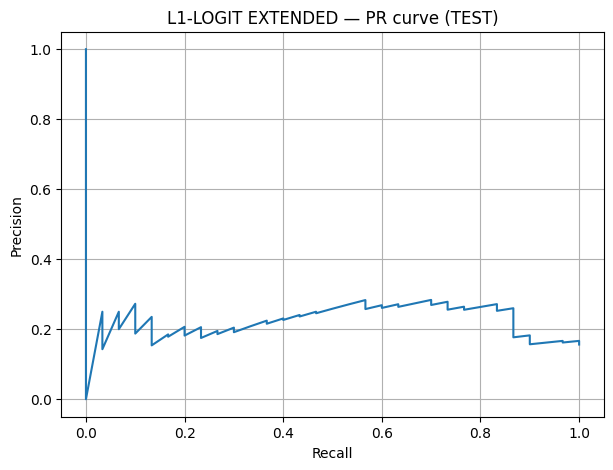


[L1-LOGIT EXTENDED TEST] ROC-AUC=0.6720 | PR-AUC=0.2362 | F1=0.3444 | thr=0.4917
Confusion:
 [[67 95]
 [ 4 26]]
              precision    recall  f1-score   support

           0      0.944     0.414     0.575       162
           1      0.215     0.867     0.344        30

    accuracy                          0.484       192
   macro avg      0.579     0.640     0.460       192
weighted avg      0.830     0.484     0.539       192


Non-zero coefficients: 4 / 60

Top 4 non-zero |coef|:
                                                                                                                                              feature      coef  odds_ratio
Значение дороги_Местного значения (дорога местного значения, включая относящиеся к собственности поселений, муниципальных районов, городских округов) -0.345433    0.707914
                                                                                                                                                month  0.045173  

In [ ]:
from sklearn.exceptions import ConvergenceWarning
import warnings

warnings.filterwarnings("ignore", category=ConvergenceWarning)

def run_logit_l1_time_split(
    features,
    label,
    C_grid=(0.02, 0.05, 0.1, 0.2, 0.5, 1.0, 2.0),
    top_k_nonzero=30
):

    X = df[features].copy()
    y = df["fatal"].astype(int)

    X_train, y_train = X.loc[train_idx], y.loc[train_idx]
    X_val,   y_val   = X.loc[val_idx],   y.loc[val_idx]
    X_test,  y_test  = X.loc[test_idx],  y.loc[test_idx]

    numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
    categorical_cols = [c for c in X.columns if c not in numeric_cols]

    pre = ColumnTransformer(
        transformers=[
            ("num", Pipeline([("imp", SimpleImputer(strategy="median"))]), numeric_cols),
            ("cat", Pipeline([
                ("imp", SimpleImputer(strategy="most_frequent")),
                ("ohe", OneHotEncoder(handle_unknown="ignore"))
            ]), categorical_cols),
        ],
        remainder="drop"
    )

    best = {"C": None, "pr_auc": -np.inf, "pipe": None}

    for C in C_grid:
        clf = LogisticRegression(
            penalty="l1",
            solver="liblinear",
            C=C,
            max_iter=5000,
            class_weight="balanced",
            random_state=RANDOM_STATE
        )
        pipe = Pipeline([("pre", pre), ("clf", clf)])
        pipe.fit(X_train, y_train)

        proba_val = pipe.predict_proba(X_val)[:, 1]
        pr = average_precision_score(y_val, proba_val)

        if pr > best["pr_auc"]:
            best = {"C": C, "pr_auc": float(pr), "pipe": pipe}

    pipe = best["pipe"]
    proba_val = pipe.predict_proba(X_val)[:, 1]
    best_thr, best_f1, best_prec, best_rec = find_best_threshold_f1(y_val.values, proba_val)

    print(f"\n===== L1-LOGIT {label} =====")
    print(f"Chosen C={best['C']} by VAL PR-AUC={best['pr_auc']:.4f}")
    print(f"VAL best_thr={best_thr:.4f} | F1={best_f1:.4f} | P={best_prec:.4f} | R={best_rec:.4f}")

    proba_test = pipe.predict_proba(X_test)[:, 1]
    plot_pr_curve(y_test.values, proba_test, title=f"L1-LOGIT {label} — PR curve (TEST)")
    metrics = eval_at_threshold(y_test.values, proba_test, best_thr, label=f"L1-LOGIT {label} TEST")

    ohe = pipe.named_steps["pre"].named_transformers_["cat"].named_steps["ohe"]
    cat_names = ohe.get_feature_names_out(categorical_cols) if len(categorical_cols) else np.array([])
    feat_names = np.concatenate([np.array(numeric_cols), cat_names])

    coefs = pipe.named_steps["clf"].coef_.ravel()
    imp = pd.DataFrame({"feature": feat_names, "coef": coefs})
    imp["abs_coef"] = imp["coef"].abs()

    nonzero = imp[imp["coef"] != 0].sort_values("abs_coef", ascending=False)
    print(f"\nNon-zero coefficients: {len(nonzero)} / {len(imp)}")

    if len(nonzero) > 0:
        print(f"\nTop {min(top_k_nonzero, len(nonzero))} non-zero |coef|:")
        tmp = nonzero.head(top_k_nonzero).copy()
        tmp["odds_ratio"] = np.exp(tmp["coef"])
        print(tmp[["feature", "coef", "odds_ratio"]].to_string(index=False))

    return pipe, metrics, nonzero, best

l1_logit_ext, met_l1_ext, nz_l1_ext, best_l1_ext = run_logit_l1_time_split(
    extended_features,
    "EXTENDED",
    C_grid=(0.02, 0.05, 0.1, 0.2, 0.5, 1.0, 2.0),
    top_k_nonzero=30
)

In [ ]:
!pip install pygam

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.6/84.6 kB 3.3 MB/s eta 0:00:00



[GAM] Using features (fixed ex-ante):
['hour', 'month', 'dow', 'n_vehicles', 'share_old20', 'Число участников']

[GAM] Chosen lam=100 by VAL PR-AUC=0.2874
[GAM] VAL best_thr=0.1392 | F1=0.3834 | P=0.2662 | R=0.6852


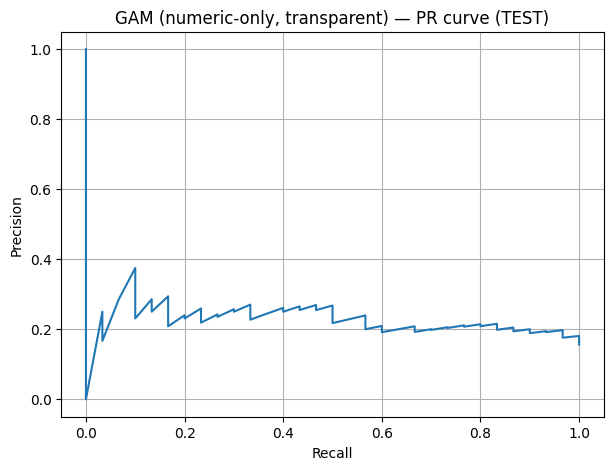


[GAM TEST] ROC-AUC=0.6551 | PR-AUC=0.2392 | F1=0.3218 | thr=0.1392
Confusion:
 [[ 46 116]
 [  2  28]]
              precision    recall  f1-score   support

           0      0.958     0.284     0.438       162
           1      0.194     0.933     0.322        30

    accuracy                          0.385       192
   macro avg      0.576     0.609     0.380       192
weighted avg      0.839     0.385     0.420       192

[GAM TEST] ROC-AUC=0.6551 | PR-AUC=0.2392

[GAM] Partial effect plots (compact grid):


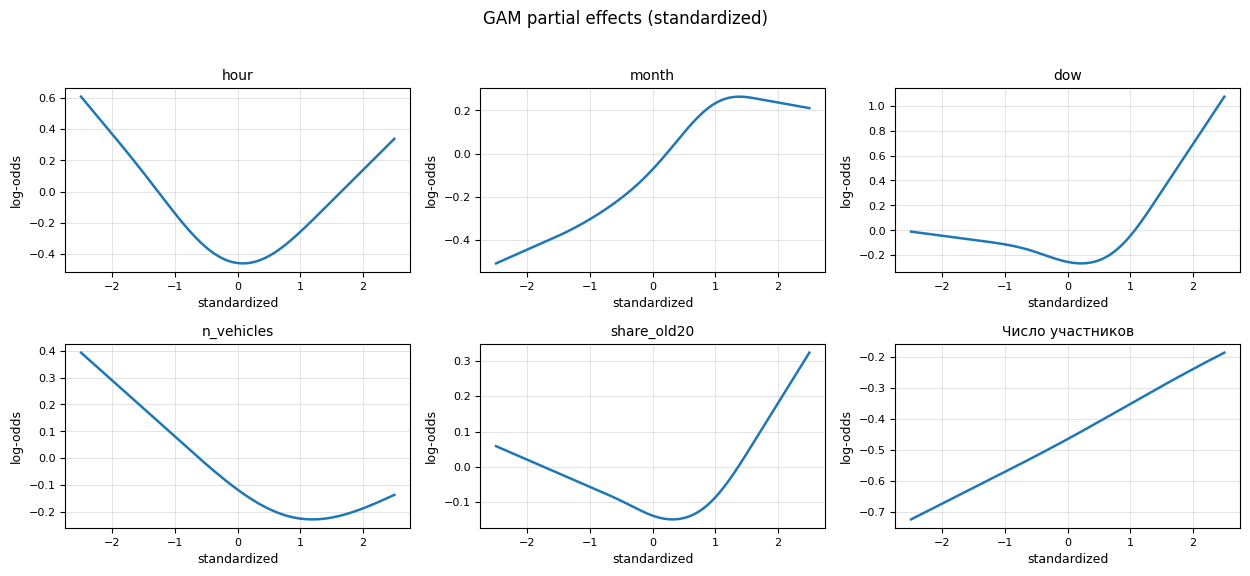

In [ ]:
from pygam import LogisticGAM, s

GAM_CANDIDATES = [
    "hour",
    "month",
    "dow",
    "n_vehicles",
    "share_old20",
    "Число участников",
]

DERIVED_DROP = ["is_weekend"]
GAM_CANDIDATES = [c for c in GAM_CANDIDATES if c not in DERIVED_DROP]

gam_features = []
for c in GAM_CANDIDATES:
    if c in df.columns and pd.api.types.is_numeric_dtype(df[c]):
        gam_features.append(c)

if len(gam_features) < 3:
    raise ValueError(f"Too few GAM features available: {gam_features}. Check df columns.")

print("\n[GAM] Using features (fixed ex-ante):")
print(gam_features)

X = df[gam_features].copy()
y = df["fatal"].astype(int)

X_train, y_train = X.loc[train_idx].copy(), y.loc[train_idx]
X_val,   y_val   = X.loc[val_idx].copy(),   y.loc[val_idx]
X_test,  y_test  = X.loc[test_idx].copy(),  y.loc[test_idx]

med = X_train.median(numeric_only=True)
X_train = X_train.fillna(med)
X_val   = X_val.fillna(med)
X_test  = X_test.fillna(med)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(X_test)

def build_terms(n_features, n_splines=15):
    terms = s(0, n_splines=n_splines)
    for i in range(1, n_features):
        terms = terms + s(i, n_splines=n_splines)
    return terms

N_SPLINES = 12
terms = build_terms(len(gam_features), n_splines=N_SPLINES)
LAM_GRID = (0.3, 1, 3, 10, 30, 100)
best = {"lam": None, "val_pr": -np.inf, "gam": None}

for lam in LAM_GRID:
    gam = LogisticGAM(terms, lam=lam)
    gam.fit(X_train_s, y_train)

    proba_val = gam.predict_proba(X_val_s)
    pr_val = average_precision_score(y_val, proba_val)

    if pr_val > best["val_pr"]:
        best = {"lam": lam, "val_pr": float(pr_val), "gam": gam}

gam = best["gam"]
print(f"\n[GAM] Chosen lam={best['lam']} by VAL PR-AUC={best['val_pr']:.4f}")

proba_val = gam.predict_proba(X_val_s)
best_thr, best_f1, best_p, best_r = find_best_threshold_f1(y_val.values, proba_val)

print(f"[GAM] VAL best_thr={best_thr:.4f} | F1={best_f1:.4f} | P={best_p:.4f} | R={best_r:.4f}")

proba_test = gam.predict_proba(X_test_s)

plot_pr_curve(y_test.values, proba_test, title="GAM (numeric-only, transparent) — PR curve (TEST)")

met = eval_at_threshold(y_test.values, proba_test, best_thr, label="GAM TEST")

met["roc_auc"] = float(roc_auc_score(y_test, proba_test))
met["pr_auc"]  = float(average_precision_score(y_test, proba_test))
print(f"[GAM TEST] ROC-AUC={met['roc_auc']:.4f} | PR-AUC={met['pr_auc']:.4f}")


try:
    from pygam.utils import generate_X_grid
    HAS_GRID = True
except Exception:
    HAS_GRID = False

def make_grid_for_term(i, grid_n=200):
    if HAS_GRID:
        return generate_X_grid(gam, term=i, n=grid_n)
    XX = np.zeros((grid_n, len(gam_features)))
    XX[:, i] = np.linspace(-2.5, 2.5, grid_n)
    return XX

def plot_gam_effects_grid(gam, gam_features, grid_n=200, ncols=3,
                          figsize_per_col=4.2, figsize_per_row=2.8):

    n = len(gam_features)
    nrows = int(np.ceil(n / ncols))

    fig, axes = plt.subplots(
        nrows=nrows, ncols=ncols,
        figsize=(figsize_per_col * ncols, figsize_per_row * nrows),
        squeeze=False
    )

    for idx, name in enumerate(gam_features):
        r, c = divmod(idx, ncols)
        ax = axes[r, c]

        XX = make_grid_for_term(idx, grid_n=grid_n)
        x = XX[:, idx]

        pdep = gam.partial_dependence(term=idx, X=XX)

        ci = None
        try:

            ci = gam.confidence_intervals(XX, term=idx, width=0.95)
        except Exception:
            try:
                ci = gam.partial_dependence(term=idx, X=XX, width=0.95)
            except Exception:
                ci = None

        ax.plot(x, pdep, linewidth=1.8)
        if isinstance(ci, np.ndarray) and ci.ndim == 2 and ci.shape[1] == 2:
            ax.fill_between(x, ci[:, 0], ci[:, 1], alpha=0.15)

        ax.set_title(name, fontsize=10)
        ax.set_xlabel("standardized", fontsize=9)
        ax.set_ylabel("log-odds", fontsize=9)
        ax.grid(True, linewidth=0.4, alpha=0.6)

        ax.tick_params(axis="both", labelsize=8)

    for j in range(n, nrows * ncols):
        r, c = divmod(j, ncols)
        axes[r, c].axis("off")

    fig.suptitle("GAM partial effects (standardized)", fontsize=12, y=1.02)
    fig.tight_layout()
    plt.show()

print("\n[GAM] Partial effect plots (compact grid):")
plot_gam_effects_grid(gam, gam_features, grid_n=200, ncols=3)


gam_out = {
    "features": gam_features,
    "lam": best["lam"],
    "best_thr": best_thr,
    "model": gam,
    "scaler": scaler,
    "median_imputer": med,
    "metrics": met
}

In [ ]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 7.8 MB/s eta 0:00:00


## CatBoost

0:	test: 0.6094968	best: 0.6094968 (0)	total: 59.6ms	remaining: 2m 28s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.632127193
bestIteration = 7

Shrink model to first 8 iterations.

===== CATBOOST STRICT =====
VAL best_thr=0.4521 | F1=0.3267 | P=0.2081 | R=0.7593


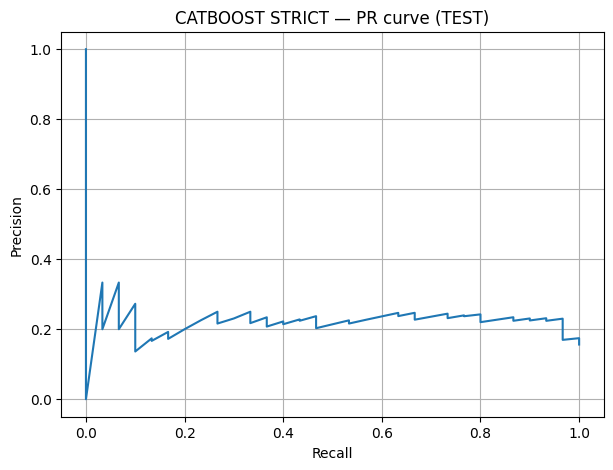


[CATBOOST STRICT TEST] ROC-AUC=0.6764 | PR-AUC=0.2357 | F1=0.3684 | thr=0.4521
Confusion:
 [[68 94]
 [ 2 28]]
              precision    recall  f1-score   support

           0      0.971     0.420     0.586       162
           1      0.230     0.933     0.368        30

    accuracy                          0.500       192
   macro avg      0.600     0.677     0.477       192
weighted avg      0.856     0.500     0.552       192


Top-20 FeatureImportance:
                 feature  importance
         Значение дороги   40.679872
               Освещение   13.228148
              n_vehicles    8.628843
                     dow    8.302953
                    hour    7.760987
Состояние проезжей части    5.115529
            has_col_dark    4.284764
             share_old20    4.044055
                   month    3.199501
                 has_car    2.140979
              is_weekend    1.773749
            mean_car_age    0.757325
        Состояние погоды    0.083296
                 

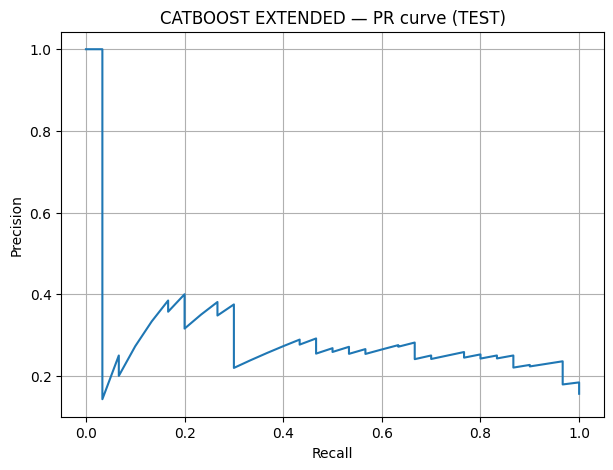


[CATBOOST EXTENDED TEST] ROC-AUC=0.7210 | PR-AUC=0.3036 | F1=0.3662 | thr=0.4789
Confusion:
 [[76 86]
 [ 4 26]]
              precision    recall  f1-score   support

           0      0.950     0.469     0.628       162
           1      0.232     0.867     0.366        30

    accuracy                          0.531       192
   macro avg      0.591     0.668     0.497       192
weighted avg      0.838     0.531     0.587       192


Top-20 FeatureImportance:
                 feature  importance
         Значение дороги   33.116041
                 Вид ДТП   17.361318
                    hour   10.695179
               Освещение    8.460001
        Число участников    7.672479
Состояние проезжей части    5.605735
                     dow    5.522828
           Количество ТС    4.151209
              n_vehicles    3.757745
             share_old20    3.219993
            mean_car_age    0.437473
        Состояние погоды    0.000000
                   month    0.000000
              i

In [ ]:
try:
    from catboost import CatBoostClassifier, Pool
except ImportError as e:
    raise ImportError("CatBoost не установлен. Установи: pip install catboost") from e

def run_catboost_time_split(features, label, iterations=2500):
    X = df[features].copy()
    y = df["fatal"].astype(int)

    X_train, y_train = X.loc[train_idx], y.loc[train_idx]
    X_val,   y_val   = X.loc[val_idx],   y.loc[val_idx]
    X_test,  y_test  = X.loc[test_idx],  y.loc[test_idx]

    cat_cols = X.select_dtypes(include=["object"]).columns.tolist()
    for c in cat_cols:
        X_train[c] = X_train[c].fillna("NA").astype(str)
        X_val[c]   = X_val[c].fillna("NA").astype(str)
        X_test[c]  = X_test[c].fillna("NA").astype(str)
    cat_idx = [X.columns.get_loc(c) for c in cat_cols]

    train_pool = Pool(X_train, y_train, cat_features=cat_idx)
    val_pool   = Pool(X_val,   y_val,   cat_features=cat_idx)
    test_pool  = Pool(X_test,  y_test,  cat_features=cat_idx)

    model = CatBoostClassifier(
    iterations=iterations,
    learning_rate=0.05,
    depth=6,
    loss_function="Logloss",
    eval_metric="AUC",
    random_seed=RANDOM_STATE,
    verbose=200,
    auto_class_weights="Balanced",
    allow_writing_files=False,
    l2_leaf_reg=3.0,

    od_type="Iter",
    od_wait=100
)

    model.fit(train_pool, eval_set=val_pool, use_best_model=True)

    proba_val = model.predict_proba(val_pool)[:, 1]
    best_thr, best_f1, best_prec, best_rec = find_best_threshold_f1(y_val.values, proba_val)

    print(f"\n===== CATBOOST {label} =====")
    print(f"VAL best_thr={best_thr:.4f} | F1={best_f1:.4f} | P={best_prec:.4f} | R={best_rec:.4f}")

    proba_test = model.predict_proba(test_pool)[:, 1]
    plot_pr_curve(y_test.values, proba_test, title=f"CATBOOST {label} — PR curve (TEST)")
    metrics = eval_at_threshold(y_test.values, proba_test, best_thr, label=f"CATBOOST {label} TEST")

    fi = pd.DataFrame({
        "feature": X.columns,
        "importance": model.get_feature_importance(train_pool, type="FeatureImportance")
    }).sort_values("importance", ascending=False)

    print("\nTop-20 FeatureImportance:")
    print(fi.head(20).to_string(index=False))

    return model, metrics, fi, (X_train, y_train, X_val, y_val, X_test, y_test, train_pool, val_pool, test_pool)

cb_strict, met_cb_strict, fi_cb_strict, pack_strict = run_catboost_time_split(strict_features, "STRICT")
cb_ext,    met_cb_ext,    fi_cb_ext,    pack_ext    = run_catboost_time_split(extended_features, "EXTENDED")

In [ ]:
!pip install lime

## SHAP


===== SHAP PLOTS: CATBOOST STRICT =====
SHAP global bar


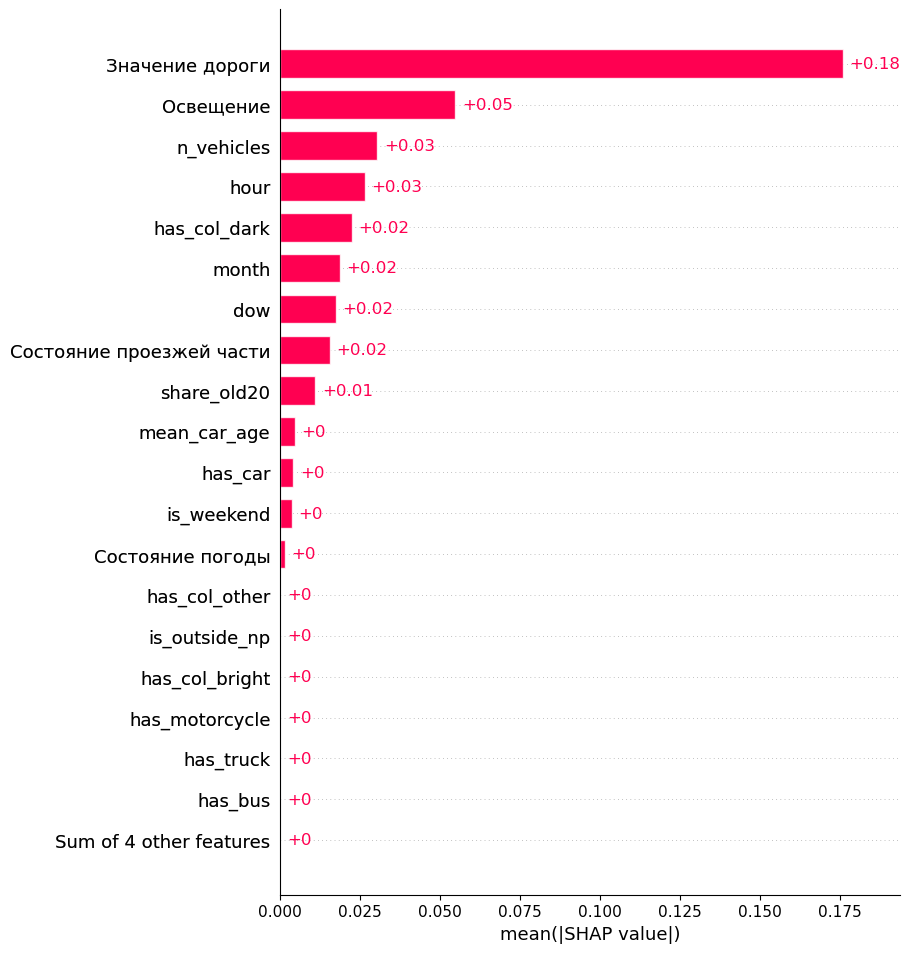

SHAP global beeswarm


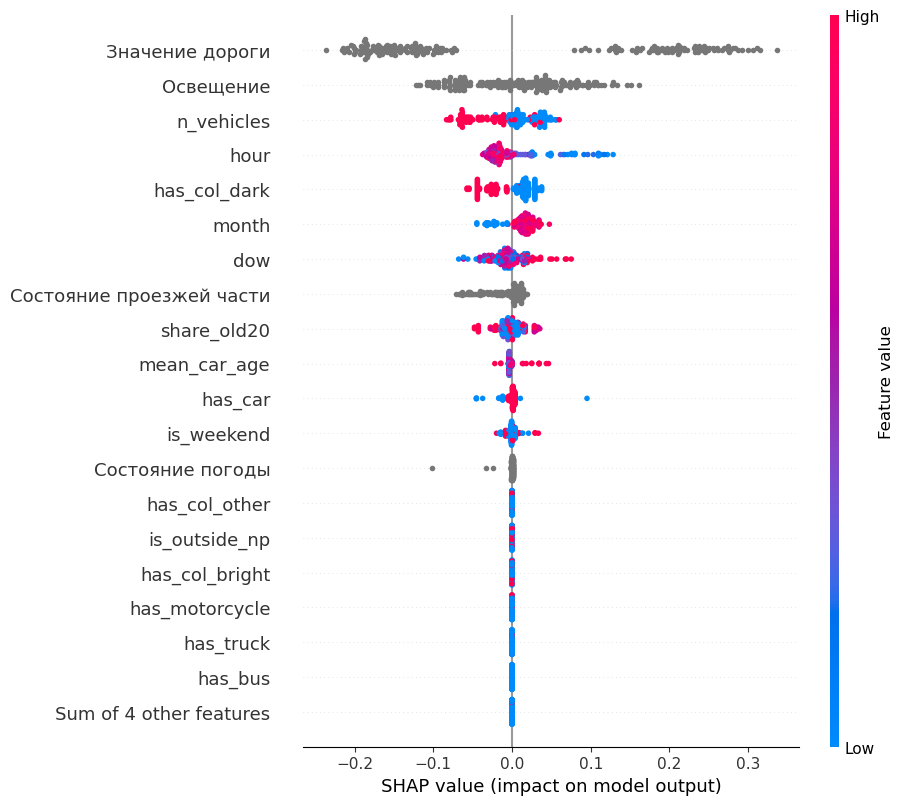

SHAP dependence: hour


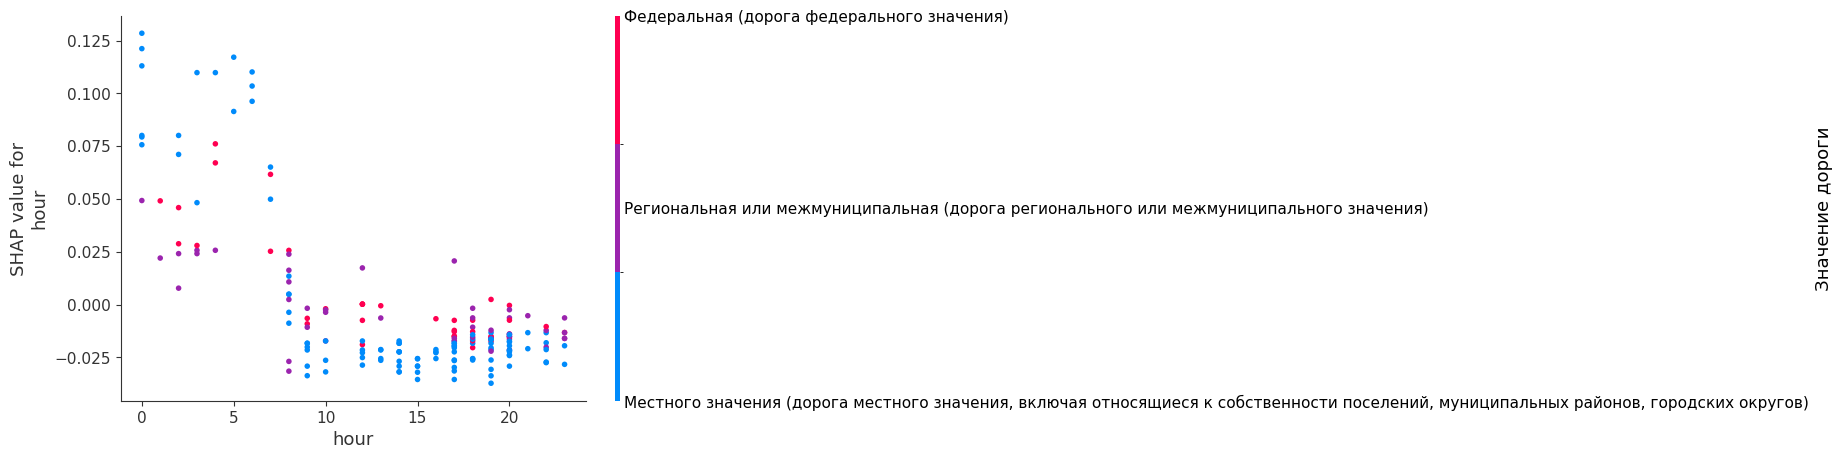

SHAP dependence: n_vehicles


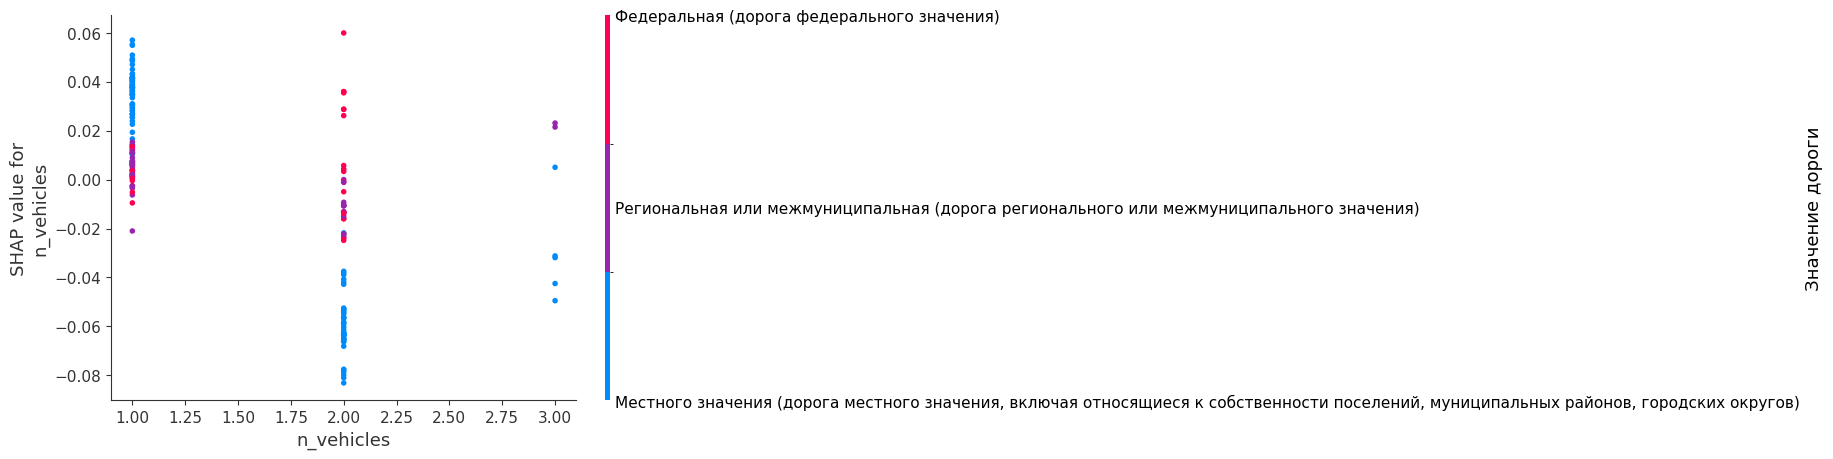

SHAP dependence: mean_car_age


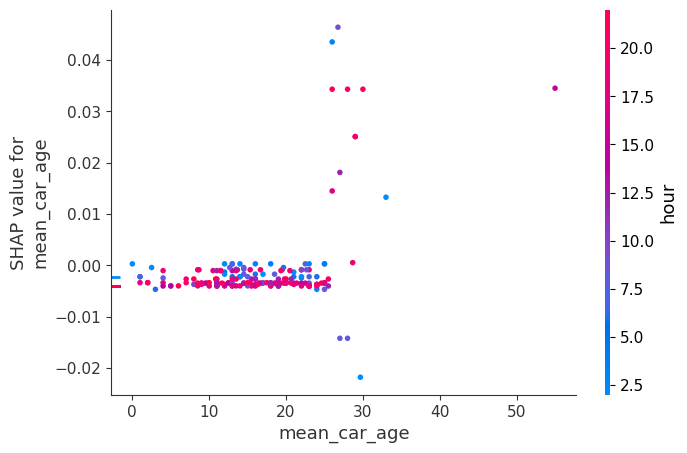


Local waterfall: highest_proba | i=106 | proba=0.574 | y=0 | pred@0.5=1


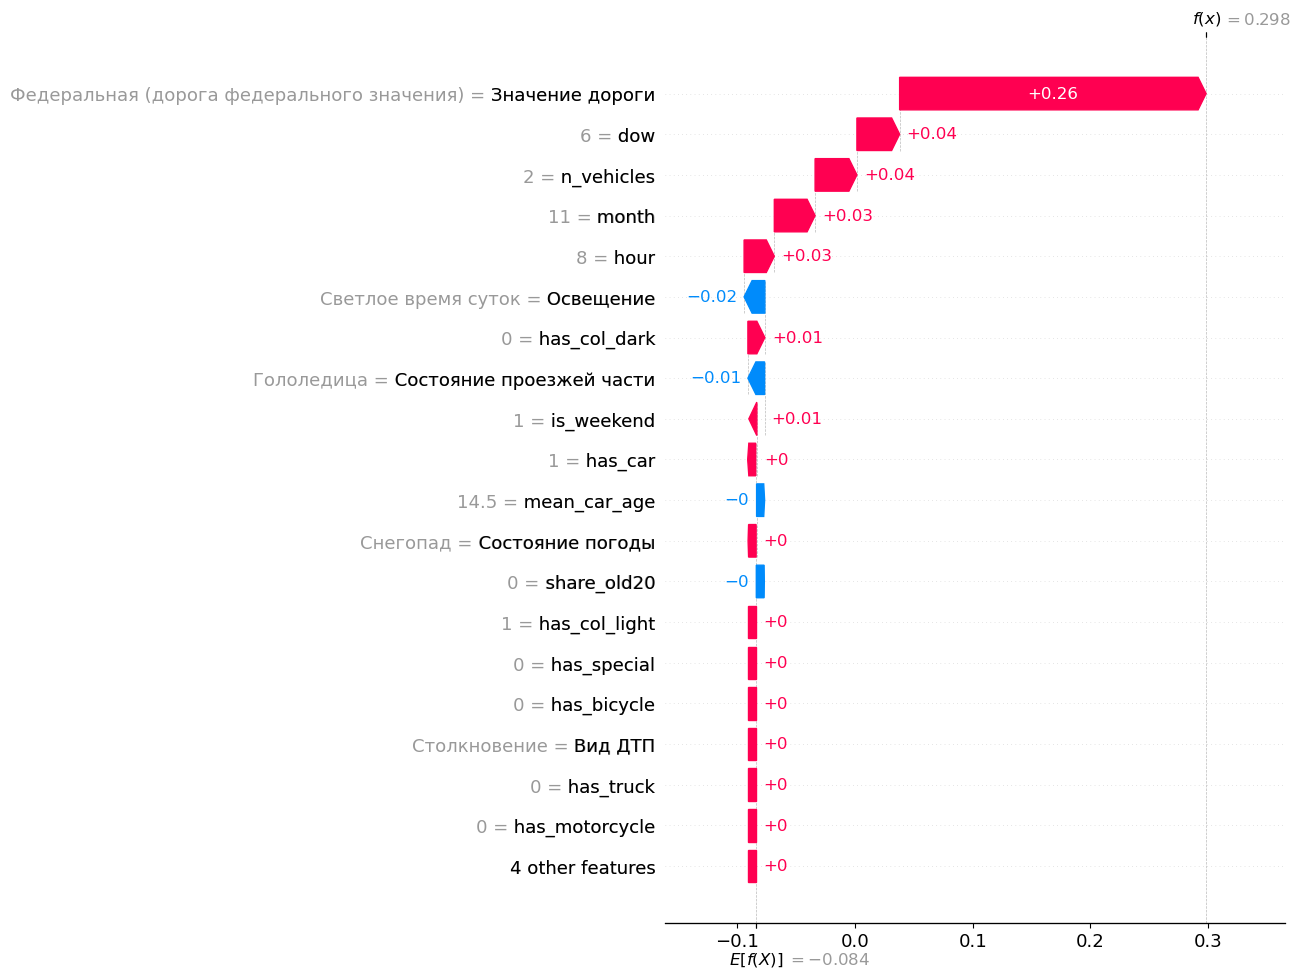


Local waterfall: lowest_proba | i=147 | proba=0.361 | y=0 | pred@0.5=0


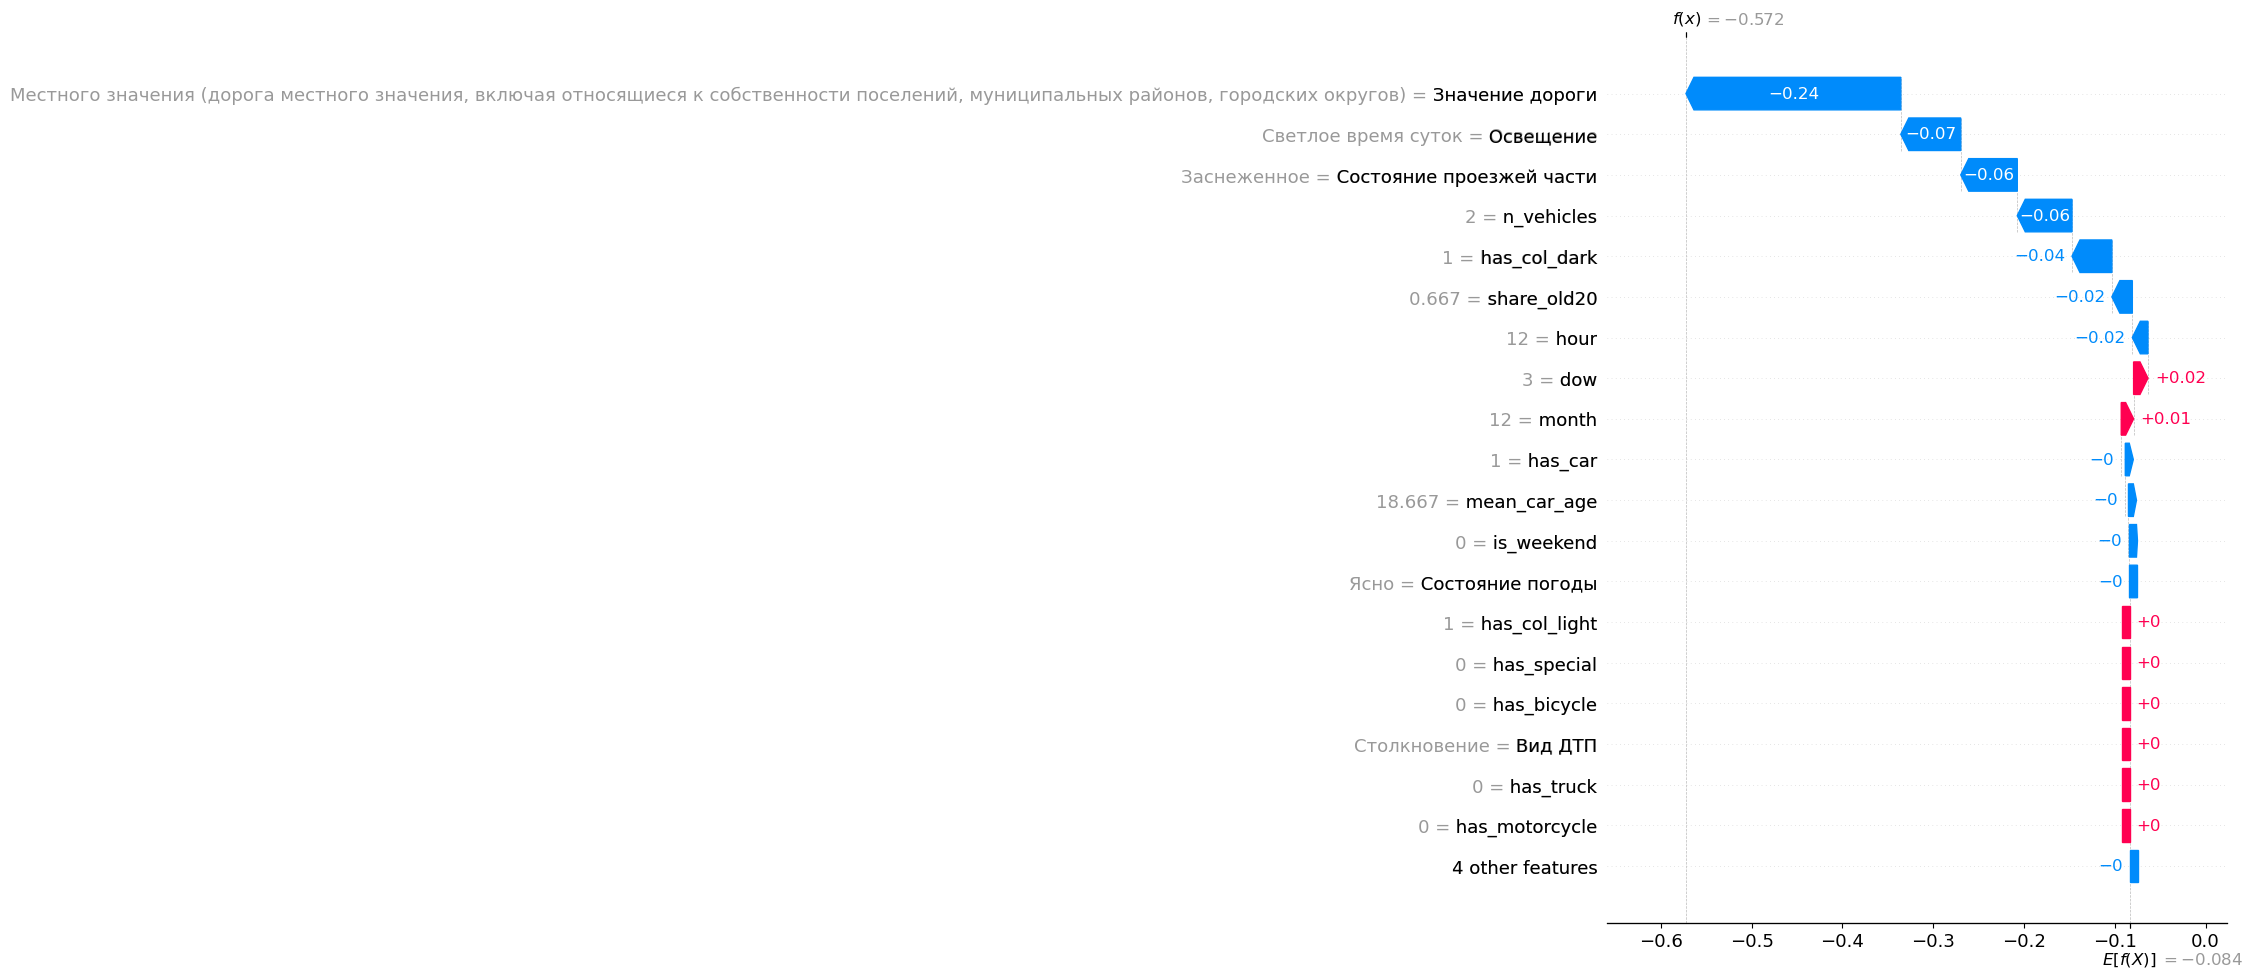


Local waterfall: first_error@0.5 | i=1 | proba=0.547 | y=0 | pred@0.5=1


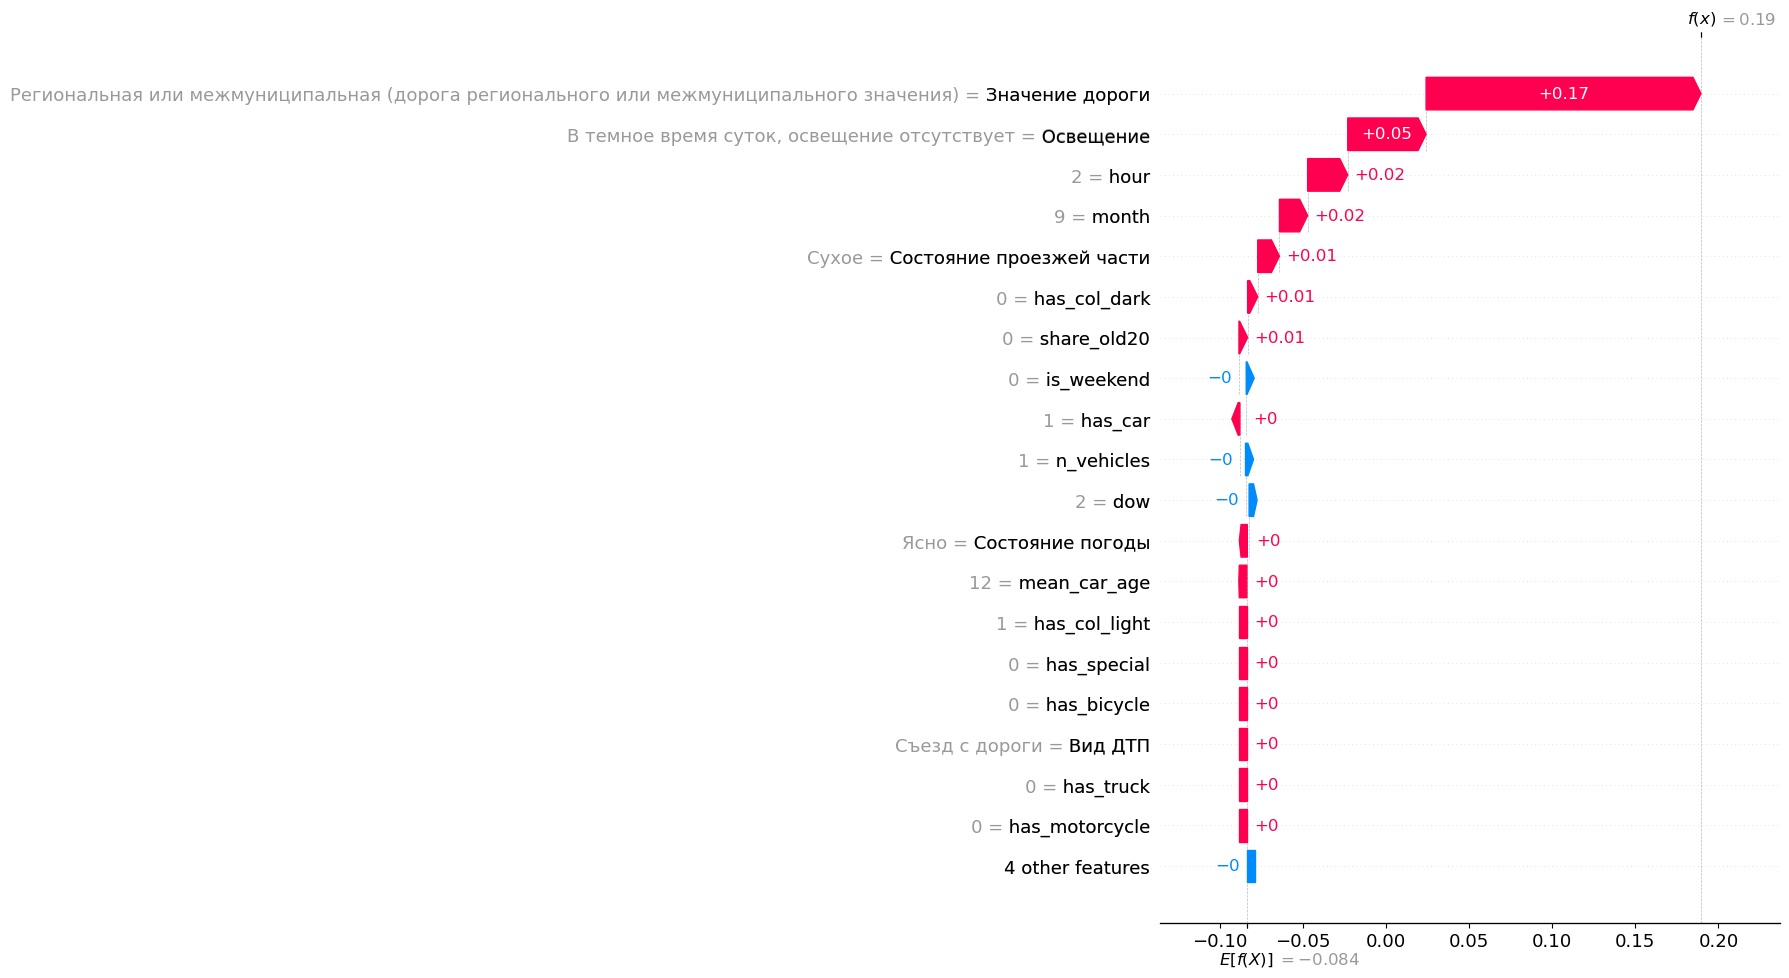


Decision plot (first 80 obs)
[WARN] decision_plot failed: ValueError: operands could not be broadcast together with shapes (80,) (80,21) 

===== SHAP PLOTS: CATBOOST EXTENDED =====
SHAP global bar


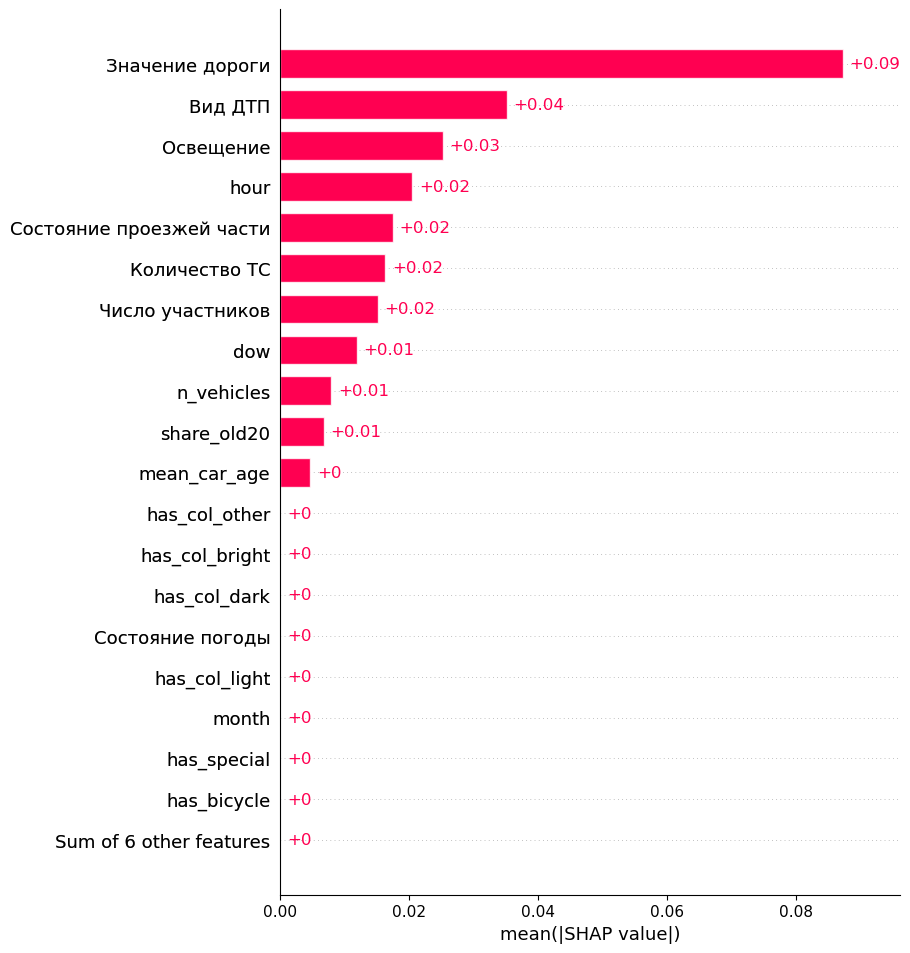

SHAP global beeswarm


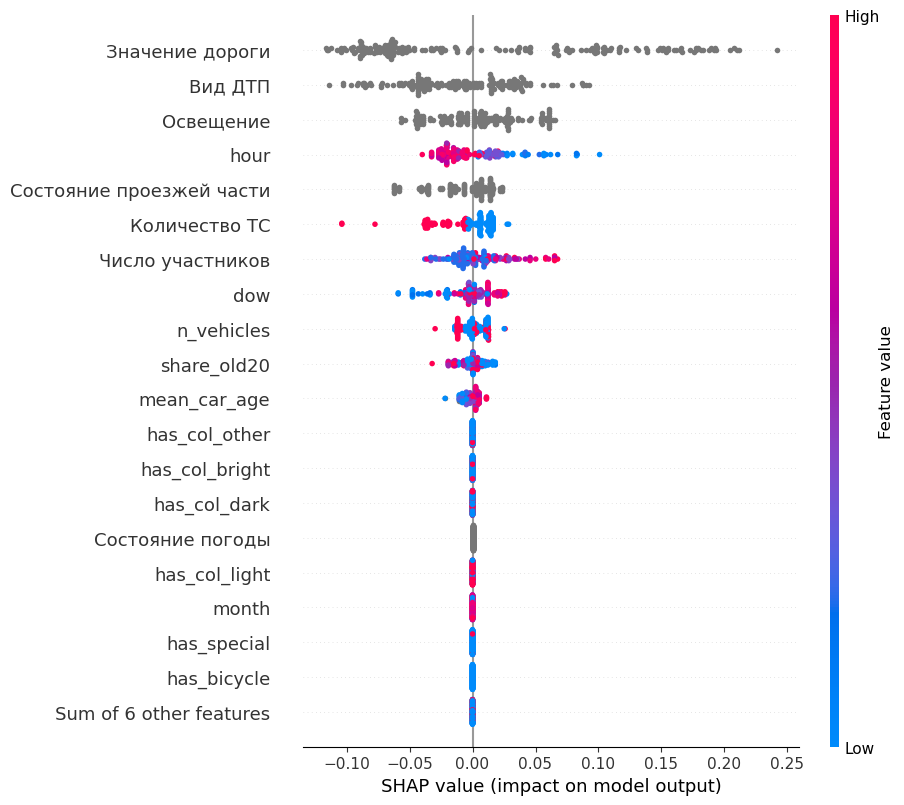

SHAP dependence: hour


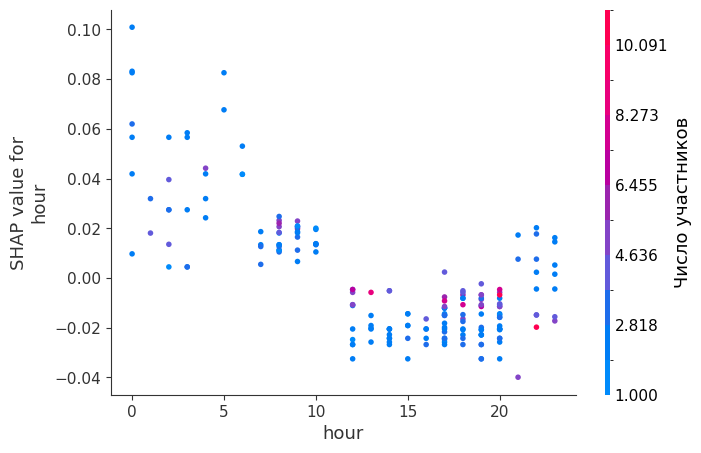

SHAP dependence: n_vehicles


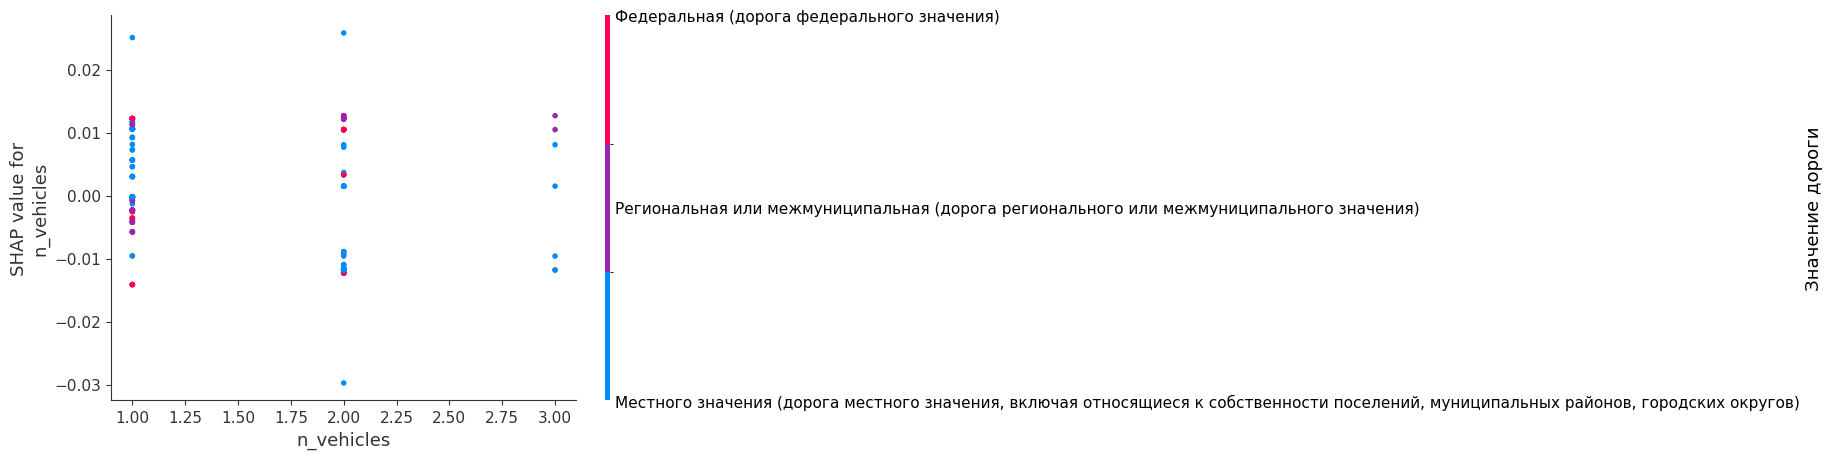

SHAP dependence: mean_car_age


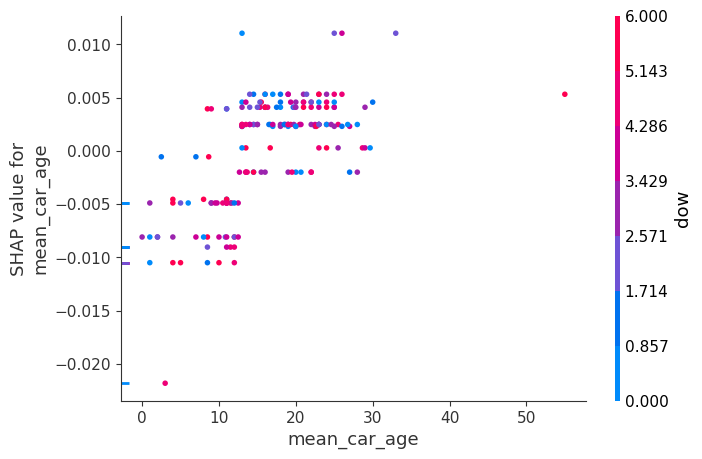


Local waterfall: highest_proba | i=48 | proba=0.558 | y=1 | pred@0.5=1


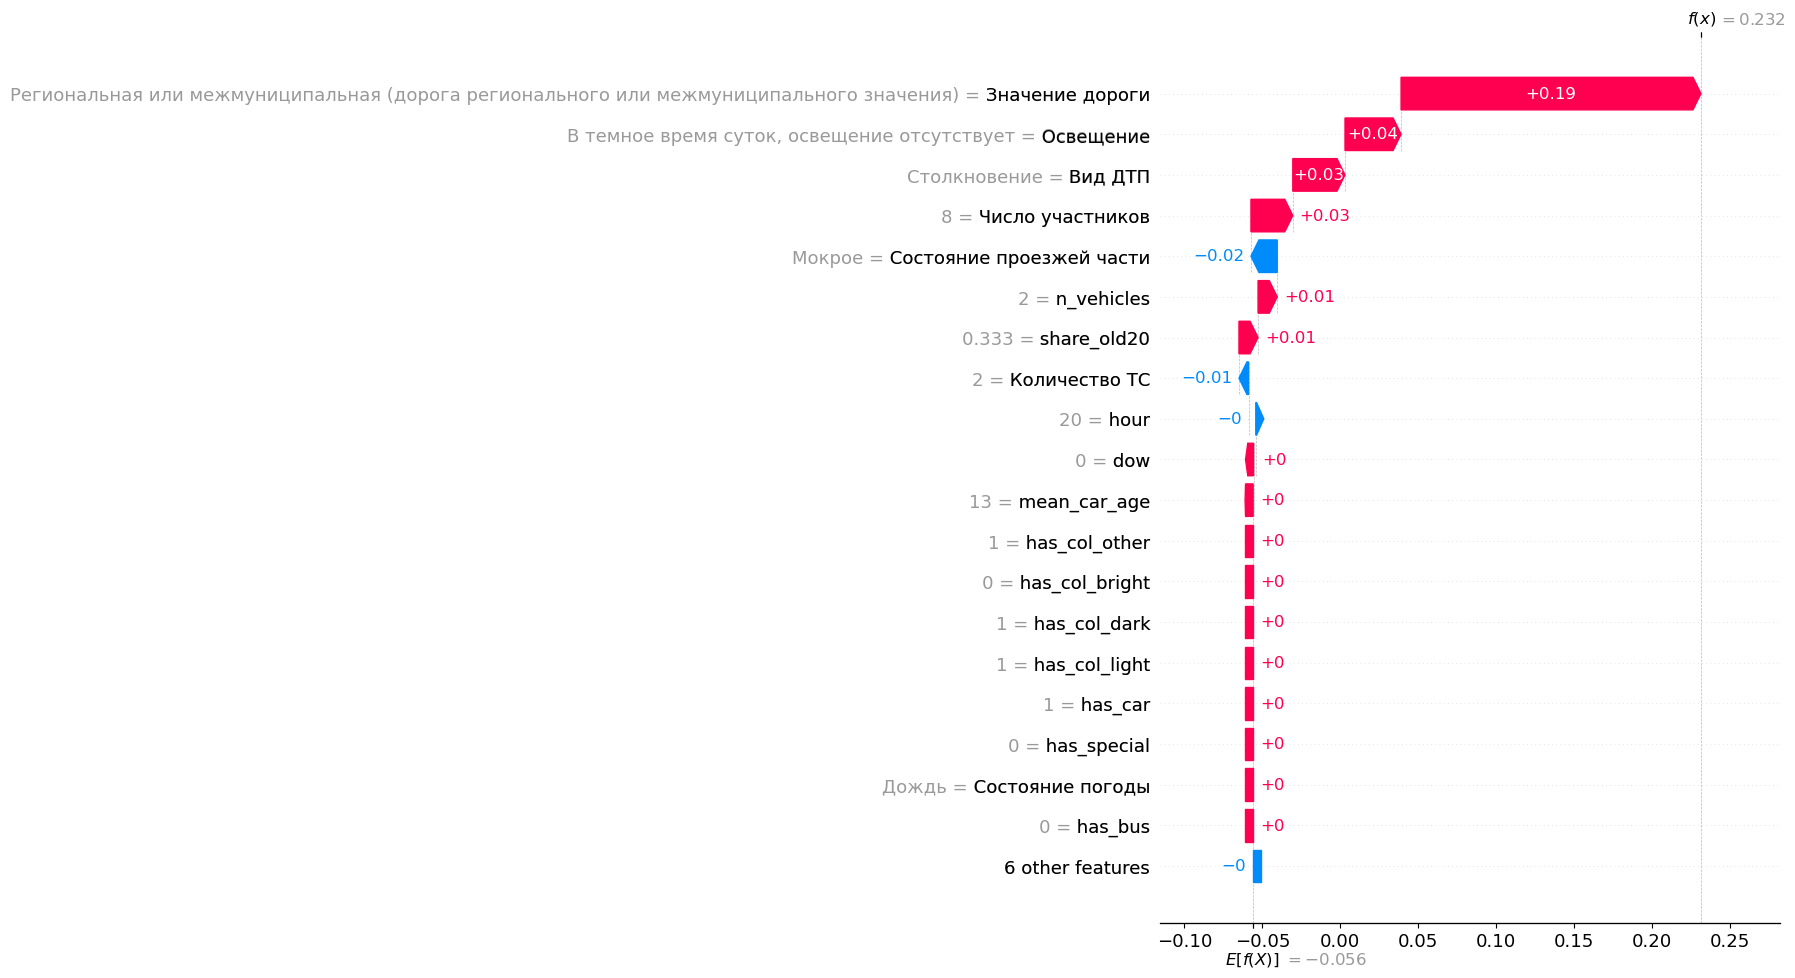


Local waterfall: lowest_proba | i=162 | proba=0.407 | y=0 | pred@0.5=0


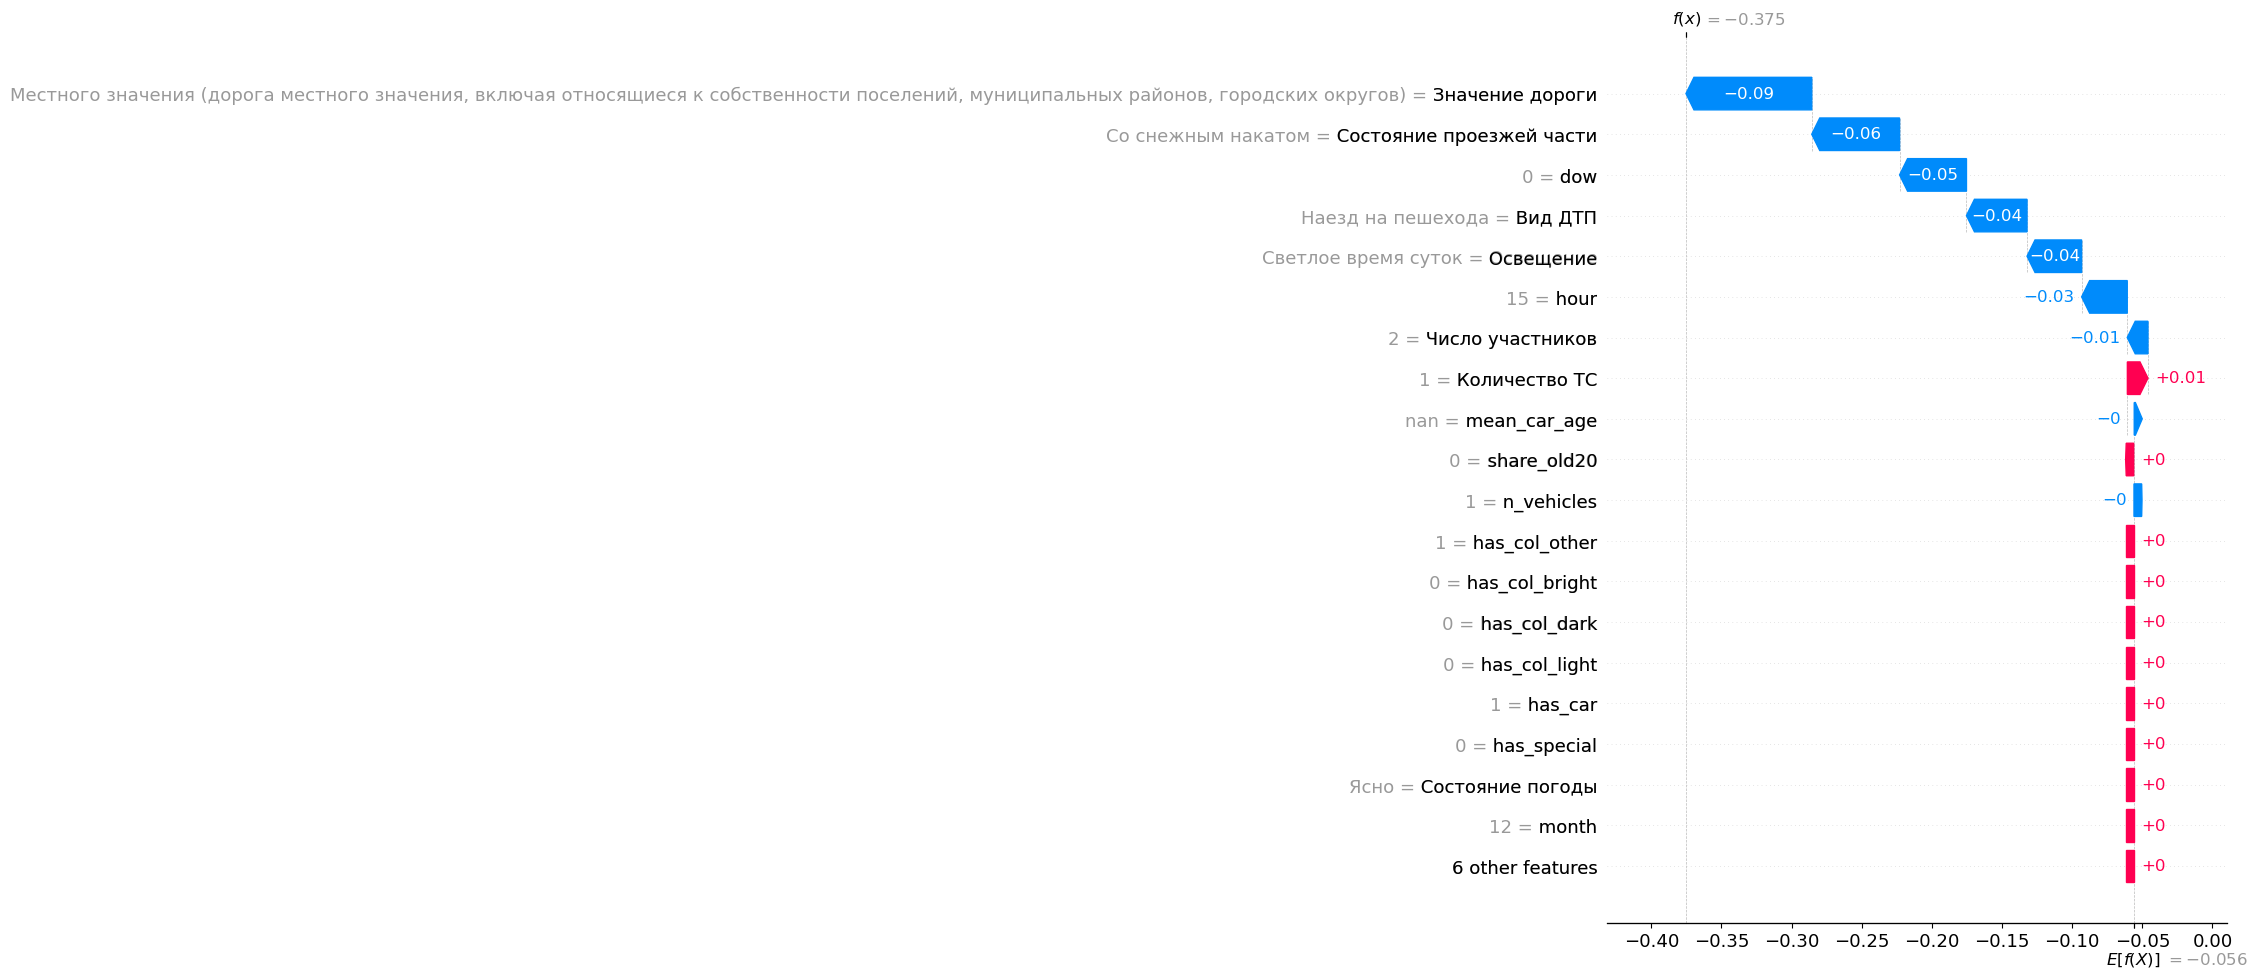


Local waterfall: first_error@0.5 | i=1 | proba=0.531 | y=0 | pred@0.5=1


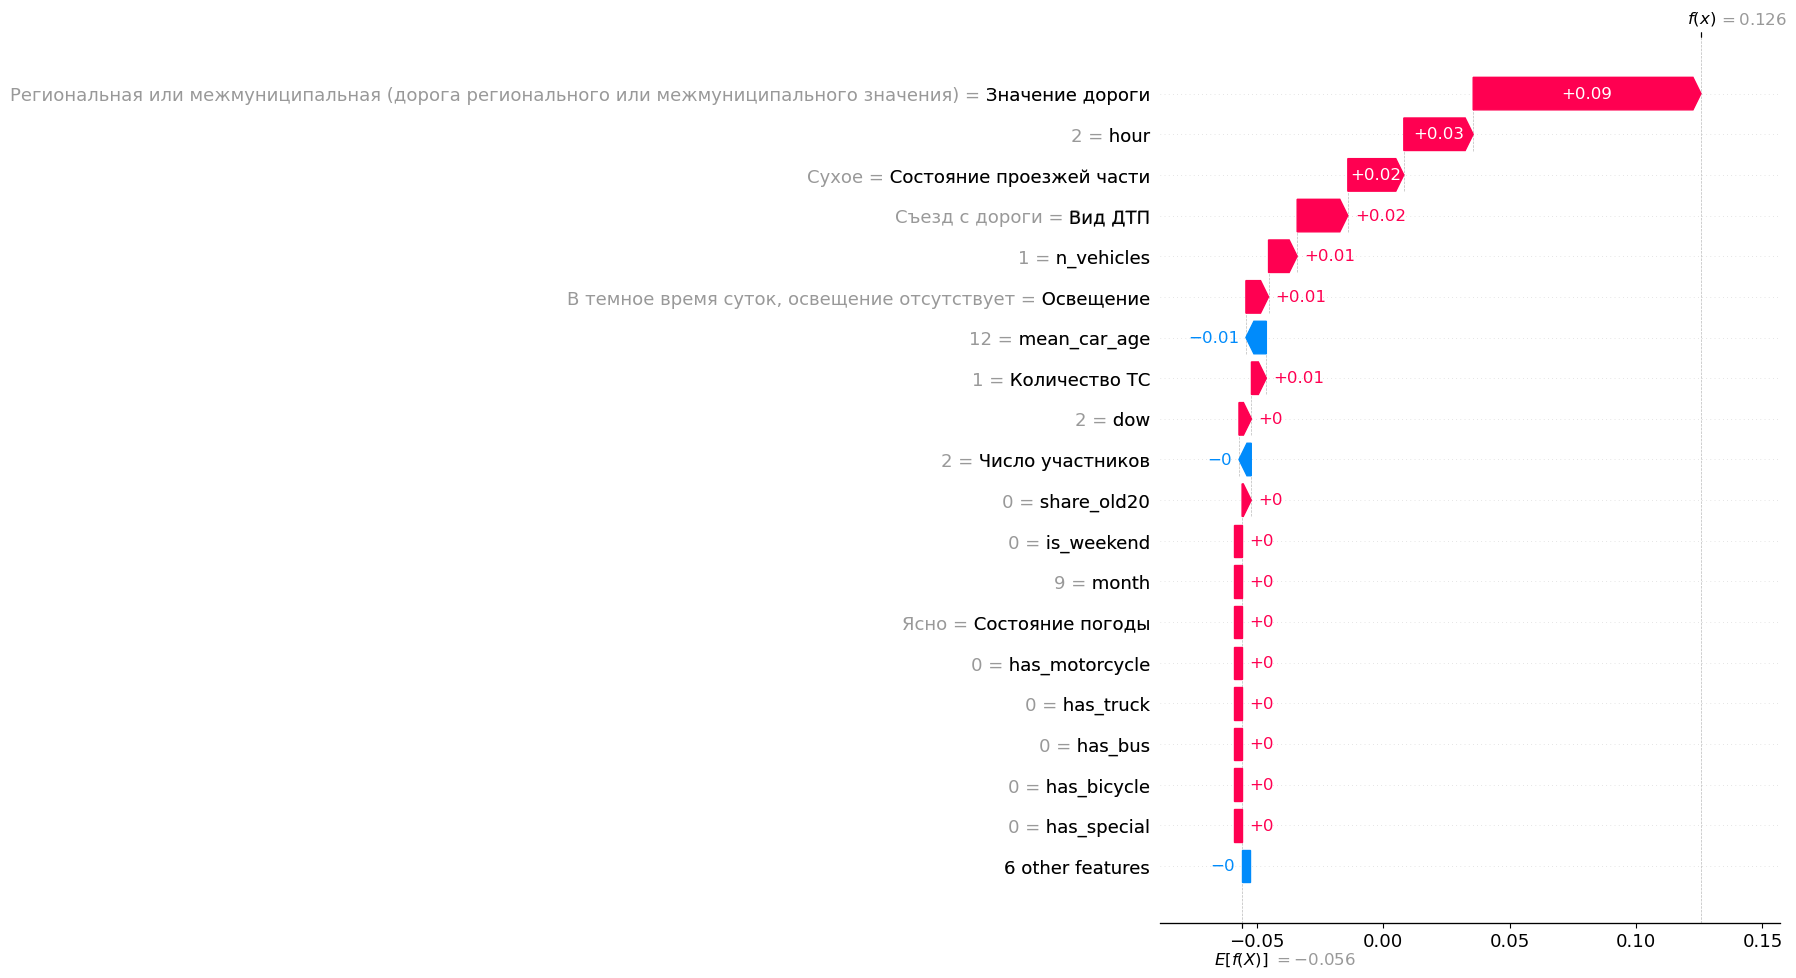


Decision plot (first 80 obs)
[WARN] decision_plot failed: ValueError: operands could not be broadcast together with shapes (80,) (80,21) 


<Figure size 1000x600 with 0 Axes>

In [ ]:
import shap

def _get_shap_for_catboost(model, X_ref, pool=None):
    try:
        explainer = shap.TreeExplainer(model, feature_perturbation="tree_path_dependent")
        sv = explainer.shap_values(X_ref)
        base = explainer.expected_value
        if isinstance(sv, list) and len(sv) == 2:
            sv = sv[1]
            if isinstance(base, (list, np.ndarray)):
                base = base[1]
        return shap.Explanation(values=sv, base_values=np.array([base]*len(X_ref)),
                               data=X_ref, feature_names=list(X_ref.columns))
    except Exception as e1:
        print(f"[WARN] shap.TreeExplainer failed: {type(e1).__name__}: {e1}")

    try:
        if pool is None:
            raise ValueError("Need CatBoost Pool for native shap fallback")
        shap_vals = np.array(model.get_feature_importance(pool, type="ShapValues"))
        contrib = shap_vals[:, :-1]
        base = shap_vals[:, -1]
        return shap.Explanation(values=contrib, base_values=base,
                               data=X_ref, feature_names=list(X_ref.columns))
    except Exception as e2:
        raise RuntimeError(f"Both SHAP methods failed: {type(e2).__name__}: {e2}")

def show_shap_pack(model, pack, label, max_display=20):
    X_train, y_train, X_val, y_val, X_test, y_test, train_pool, val_pool, test_pool = pack
    shap_exp = _get_shap_for_catboost(model, X_test, pool=test_pool)

    print(f"\n===== SHAP PLOTS: {label} =====")

    print("SHAP global bar")
    shap.plots.bar(shap_exp, max_display=max_display, show=True)

    print("SHAP global beeswarm")
    shap.plots.beeswarm(shap_exp, max_display=max_display, show=True)

    numeric_candidates = ["hour", "n_vehicles", "mean_car_age", "min_car_age", "max_car_age"]
    available = [c for c in numeric_candidates if c in X_test.columns and pd.api.types.is_numeric_dtype(X_test[c])]
    available = available[:3]

    for col in available:
        print(f"SHAP dependence: {col}")
        try:
            shap.dependence_plot(col, shap_exp.values, X_test, show=True)
        except Exception as e:
            print(f"[WARN] dependence_plot failed for {col}: {type(e).__name__}: {e}")

    proba = model.predict_proba(test_pool)[:, 1]
    pred05 = (proba >= 0.5).astype(int)
    ytrue = y_test.values

    idx_hi = int(np.argmax(proba))
    idx_lo = int(np.argmin(proba))
    err_idx = None
    for i in range(len(ytrue)):
        if int(pred05[i]) != int(ytrue[i]):
            err_idx = i
            break

    chosen = [("highest_proba", idx_hi), ("lowest_proba", idx_lo)]
    if err_idx is not None:
        chosen.append(("first_error@0.5", err_idx))

    for tag, i in chosen:
        print(f"\nLocal waterfall: {tag} | i={i} | proba={proba[i]:.3f} | y={int(ytrue[i])} | pred@0.5={int(pred05[i])}")
        try:
            shap.plots.waterfall(shap_exp[i], max_display=max_display, show=True)
        except Exception as e:
            print(f"[WARN] waterfall failed: {type(e).__name__}: {e}")

    n_show = min(80, X_test.shape[0])
    print(f"\nDecision plot (first {n_show} obs)")
    try:
        plt.figure(figsize=(10, 6))
        shap.decision_plot(shap_exp.base_values[:n_show], shap_exp.values[:n_show, :], X_test.iloc[:n_show, :], show=True)
        plt.show()
    except Exception as e:
        print(f"[WARN] decision_plot failed: {type(e).__name__}: {e}")

    return shap_exp

shap_exp_strict = show_shap_pack(cb_strict, pack_strict, "CATBOOST STRICT", max_display=20)
shap_exp_ext    = show_shap_pack(cb_ext,    pack_ext,    "CATBOOST EXTENDED", max_display=20)

## LIME

In [ ]:
from dataclasses import dataclass

@dataclass
class LimeEncoder:
    cat_cols: list
    cat_idx: list
    maps: dict
    inv_maps: dict

def fit_lime_encoder(X_train: pd.DataFrame) -> LimeEncoder:
    cat_cols = X_train.select_dtypes(include=["object"]).columns.tolist()
    cat_idx = [X_train.columns.get_loc(c) for c in cat_cols]

    maps = {}
    inv_maps = {}

    for c in cat_cols:
        vals = X_train[c].fillna("NA").astype(str)
        uniq = pd.Index(vals.unique()).sort_values()
        m = {v: i for i, v in enumerate(uniq)}
        im = {i: v for v, i in m.items()}
        maps[c] = m
        inv_maps[c] = im

    return LimeEncoder(cat_cols=cat_cols, cat_idx=cat_idx, maps=maps, inv_maps=inv_maps)

def encode_for_lime(X: pd.DataFrame, enc: LimeEncoder) -> pd.DataFrame:
    Xn = X.copy()
    for c in enc.cat_cols:
        Xn[c] = Xn[c].fillna("NA").astype(str).map(enc.maps[c]).fillna(-1).astype(int)
    return Xn

def decode_from_lime(X_num: pd.DataFrame, enc: LimeEncoder) -> pd.DataFrame:
    Xd = X_num.copy()
    for c in enc.cat_cols:
        Xd[c] = Xd[c].astype(int).map(enc.inv_maps[c]).fillna("NA").astype(str)
    return Xd

In [ ]:
from lime.lime_tabular import LimeTabularExplainer
from catboost import Pool

def lime_for_catboost_robust(
    model,
    pack,
    label,
    n_cases=3,
    num_features=12,
    var_epsilon=1e-12,
    discretize_continuous=False
):
    X_train, y_train, X_val, y_val, X_test, y_test, train_pool, val_pool, test_pool = pack

    enc = fit_lime_encoder(X_train)

    Xtr_num_full = encode_for_lime(X_train, enc)
    Xte_num_full = encode_for_lime(X_test, enc)

    all_cols = list(X_train.columns)
    cat_cols = enc.cat_cols
    cont_cols = [c for c in all_cols if c not in cat_cols]

    drop_cols = []
    const_fill = {}
    for c in cont_cols:
        v = Xtr_num_full[c].to_numpy(dtype=float)
        var = np.nanvar(v)
        if not np.isfinite(var) or var <= var_epsilon:
            drop_cols.append(c)
            const_fill[c] = float(np.nanmedian(v)) if np.isfinite(np.nanmedian(v)) else 0.0

    if drop_cols:
        print(f"[LIME] Dropping near-constant continuous cols (n={len(drop_cols)}):")
        print(drop_cols[:30], ("..." if len(drop_cols) > 30 else ""))

    keep_cols = [c for c in all_cols if c not in drop_cols]
    Xtr_num = Xtr_num_full[keep_cols].copy()
    Xte_num = Xte_num_full[keep_cols].copy()

    cat_cols_kept = [c for c in cat_cols if c in keep_cols]
    cat_idx = [keep_cols.index(c) for c in cat_cols_kept]

    categorical_names = {}
    for c in cat_cols_kept:
        orig_idx = all_cols.index(c)
        inv = enc.inv_maps[c]
        max_code = max(inv.keys()) if len(inv) else -1
        names = [inv[i] for i in range(max_code + 1)] if max_code >= 0 else []
        categorical_names[keep_cols.index(c)] = names

    explainer = LimeTabularExplainer(
        training_data=Xtr_num.to_numpy(),
        feature_names=keep_cols,
        class_names=["nonfatal", "fatal"],
        categorical_features=cat_idx if cat_idx else None,
        categorical_names=categorical_names if cat_idx else None,
        mode="classification",
        discretize_continuous=discretize_continuous,
        random_state=RANDOM_STATE
    )

    proba = model.predict_proba(test_pool)[:, 1]
    pred05 = (proba >= 0.5).astype(int)
    ytrue = y_test.values

    idx_hi = int(np.argmax(proba))
    idx_lo = int(np.argmin(proba))
    err_idx = None
    for i in range(len(ytrue)):
        if int(pred05[i]) != int(ytrue[i]):
            err_idx = i
            break

    chosen = [("highest_proba", idx_hi), ("lowest_proba", idx_lo)]
    if err_idx is not None:
        chosen.append(("first_error@0.5", int(err_idx)))
    chosen = chosen[:n_cases]

    def predict_fn(x_np):
        X_tmp_num = pd.DataFrame(x_np, columns=keep_cols)

        X_full_num = pd.DataFrame(columns=all_cols)
        for c in keep_cols:
            X_full_num[c] = X_tmp_num[c].values

        for c in drop_cols:
            X_full_num[c] = const_fill.get(c, 0.0)

        X_full = X_full_num.copy()
        for c in enc.cat_cols:
            X_full[c] = X_full[c].astype(int).map(enc.inv_maps[c]).fillna("NA").astype(str)

        for c in cont_cols:
            X_full[c] = pd.to_numeric(X_full[c], errors="coerce")

        cb_cat_idx = [all_cols.index(c) for c in enc.cat_cols]
        pool = Pool(X_full[all_cols], cat_features=cb_cat_idx)
        return model.predict_proba(pool)

    print(f"\n===== LIME local explanations: {label} (TEST) =====")
    for tag, i in chosen:
        row = Xte_num.iloc[i].to_numpy()

        exp = explainer.explain_instance(
            data_row=row,
            predict_fn=predict_fn,
            num_features=num_features
        )

        print(f"\n--- {tag} | i={i} | proba={proba[i]:.3f} | y={int(ytrue[i])} | pred@0.5={int(pred05[i])} ---")
        for feat, w in exp.as_list(label=1):
            print(f"{feat:70s} {w:+.4f}")

    return {"encoder": enc, "keep_cols": keep_cols, "dropped_cols": drop_cols}

lime_meta_strict = lime_for_catboost_robust(cb_strict, pack_strict, "CATBOOST STRICT", n_cases=3, num_features=12)


===== LIME local explanations: CATBOOST STRICT (TEST) =====

--- highest_proba | i=106 | proba=0.574 | y=0 | pred@0.5=1 ---
Значение дороги=Федеральная (дорога федерального значения)             +0.0641
Освещение=Светлое время суток                                          -0.0285
has_col_dark                                                           -0.0068
Состояние проезжей части=Гололедица                                    -0.0065
hour                                                                   -0.0065
Состояние погоды=Снегопад                                              -0.0049
n_vehicles                                                             -0.0044
month                                                                  +0.0041
Вид ДТП=Столкновение                                                   +0.0021
is_weekend                                                             -0.0016
dow                                                                    +0.0014
share_

In [ ]:
summary = pd.DataFrame([
    {"model": "LOGIT_STRICT", **met_logit_strict},
    {"model": "LOGIT_EXT",    **met_logit_ext},
    {"model": "CB_STRICT",    **met_cb_strict},
    {"model": "CB_EXT",       **met_cb_ext},
])

summary

,model,roc_auc,pr_auc,f1,thr
0,LOGIT_STRICT,0.666667,0.260175,0.277778,0.641035
1,LOGIT_EXT,0.686420,0.269767,0.352941,0.386932
2,CB_STRICT,0.676440,0.235710,0.368421,0.452066
3,CB_EXT,0.720988,0.303584,0.366197,0.478888


## RANDOM FOREST


===== RANDOM FOREST STRICT =====
VAL best_thr=0.2599 | F1=0.3333 | P=0.2292 | R=0.6111
VAL ROC-AUC=0.6282 | VAL PR-AUC=0.2101


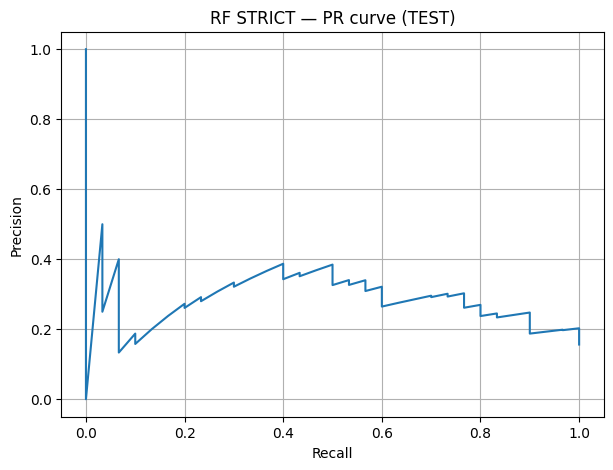


[RF STRICT TEST] ROC-AUC=0.7407 | PR-AUC=0.3001 | F1=0.3830 | thr=0.2599
Confusion:
 [[78 84]
 [ 3 27]]
              precision    recall  f1-score   support

           0      0.963     0.481     0.642       162
           1      0.243     0.900     0.383        30

    accuracy                          0.547       192
   macro avg      0.603     0.691     0.512       192
weighted avg      0.851     0.547     0.602       192

[RF TEST] ROC-AUC=0.7407 | PR-AUC=0.3001

--- Permutation importance (on TEST, raw features) ---
                 feature  importance_mean  importance_std
                 Вид ДТП         0.055692        0.024832
         Значение дороги         0.035024        0.032254
                     dow         0.030126        0.011066
              is_weekend         0.006761        0.009224
                 has_car         0.003984        0.004162
           has_col_other         0.003033        0.001863
             share_old20         0.002701        0.007852
       

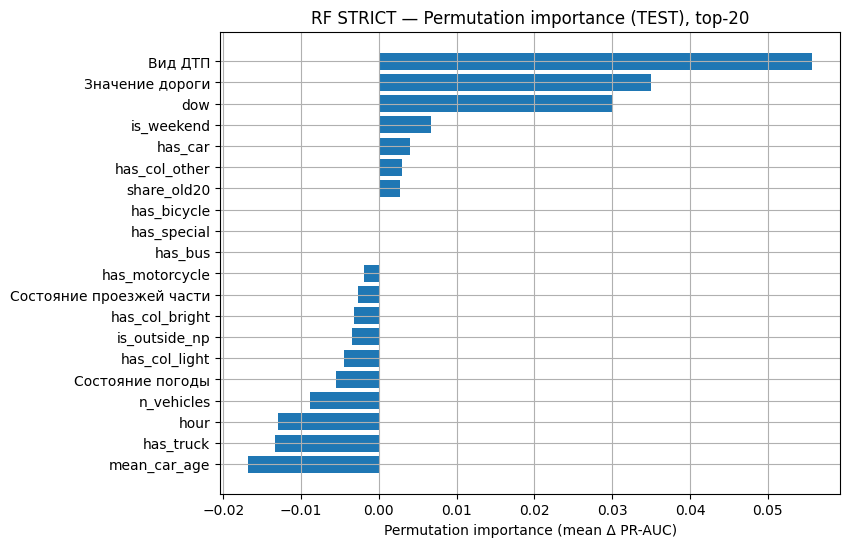


--- PDP/ICE on TEST: ['hour', 'n_vehicles', 'share_old20', 'month'] | kind=both ---


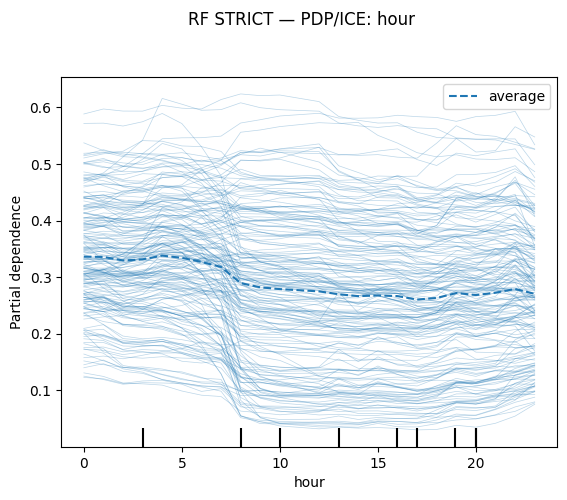

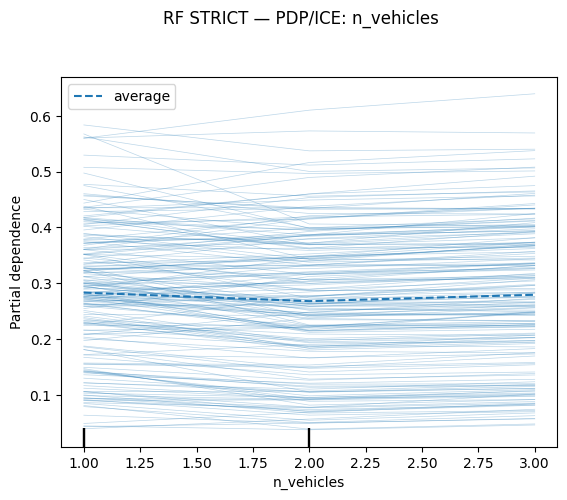

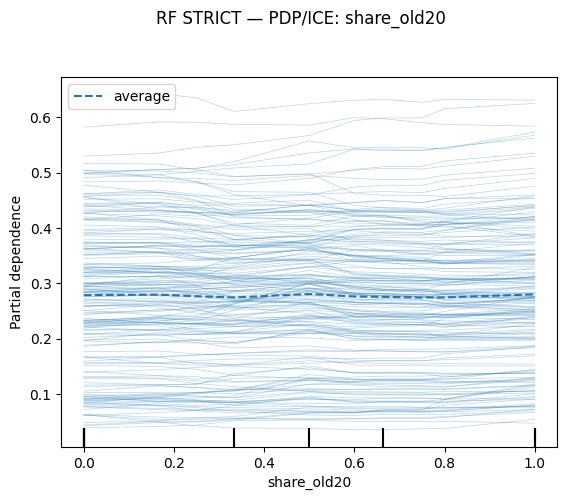

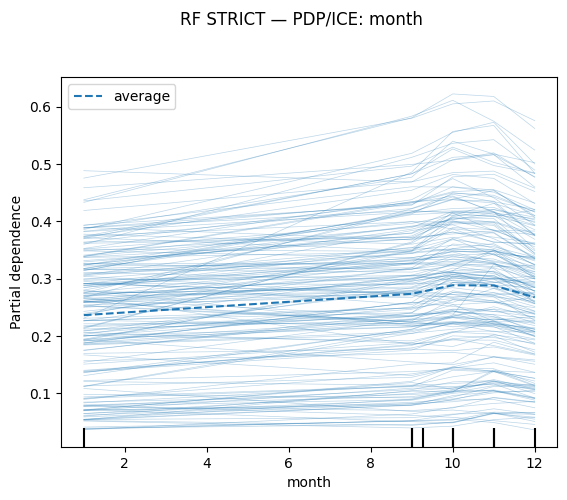


===== RANDOM FOREST EXTENDED =====
VAL best_thr=0.2605 | F1=0.3441 | P=0.2424 | R=0.5926
VAL ROC-AUC=0.6473 | VAL PR-AUC=0.2205


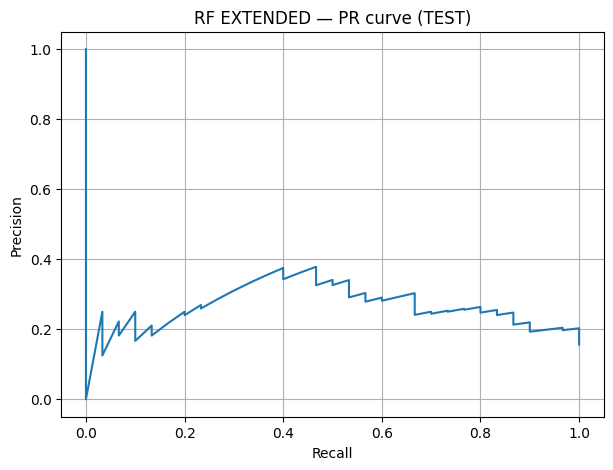


[RF EXTENDED TEST] ROC-AUC=0.7278 | PR-AUC=0.2764 | F1=0.3768 | thr=0.2605
Confusion:
 [[80 82]
 [ 4 26]]
              precision    recall  f1-score   support

           0      0.952     0.494     0.650       162
           1      0.241     0.867     0.377        30

    accuracy                          0.552       192
   macro avg      0.597     0.680     0.514       192
weighted avg      0.841     0.552     0.608       192

[RF TEST] ROC-AUC=0.7278 | PR-AUC=0.2764

--- Permutation importance (on TEST, raw features) ---
                 feature  importance_mean  importance_std
                 Вид ДТП         0.048321        0.019408
         Значение дороги         0.024774        0.027652
                     dow         0.011382        0.012905
              is_weekend         0.002425        0.008187
           has_col_other         0.002150        0.005333
           is_outside_np         0.001588        0.014533
          has_col_bright         0.000667        0.002665
     

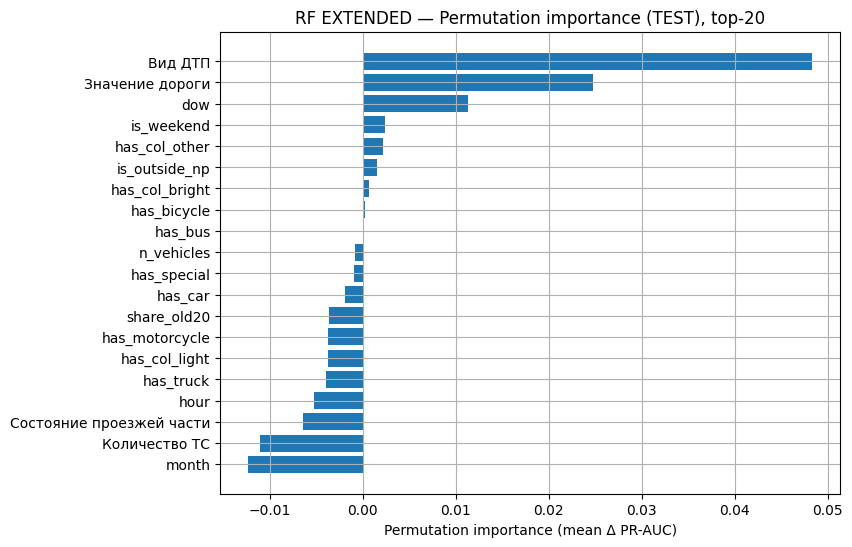


--- PDP/ICE on TEST: ['hour', 'n_vehicles', 'share_old20', 'month'] | kind=both ---


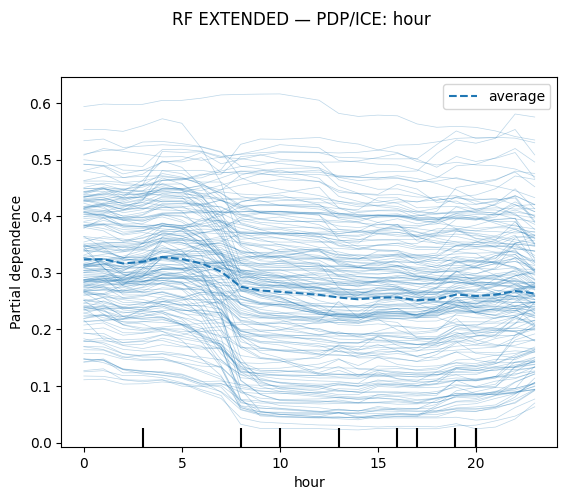

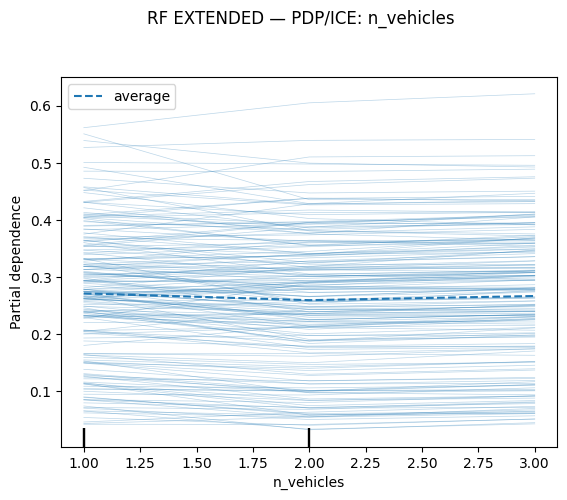

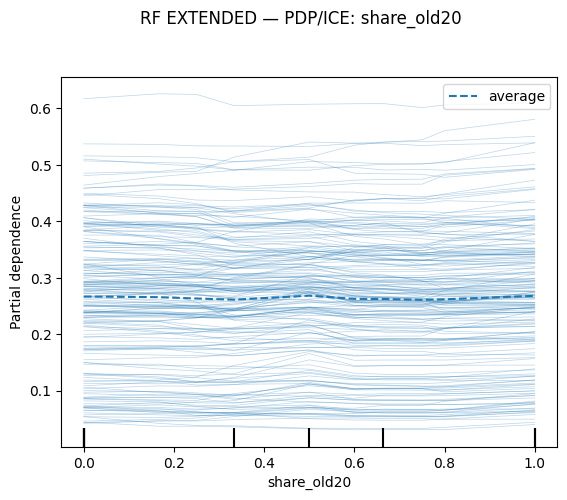

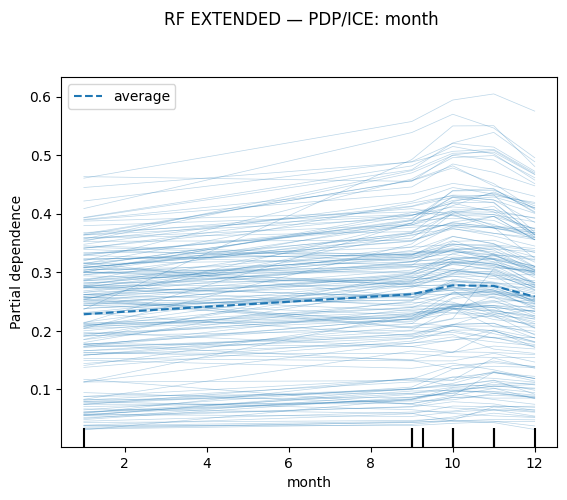

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance, PartialDependenceDisplay
from sklearn.metrics import average_precision_score, roc_auc_score


def run_random_forest_time_split(
    features,
    label,
    n_estimators=800,
    max_depth=None,
    min_samples_leaf=2,
    max_features="sqrt",
    n_jobs=-1,
    perm_repeats=10,
    pdp_features=None,
    pdp_kind=("average", "individual"),
):


    X = df[features].copy()
    y = df["fatal"].astype(int)

    X_train = X.loc[train_idx].copy()
    y_train = y.loc[train_idx].copy()

    X_val = X.loc[val_idx].copy()
    y_val = y.loc[val_idx].copy()

    X_test = X.loc[test_idx].copy()
    y_test = y.loc[test_idx].copy()

    numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
    categorical_cols = [c for c in X.columns if c not in numeric_cols]

    pre = ColumnTransformer(
        transformers=[
            ("num", Pipeline([
                ("imp", SimpleImputer(strategy="median")),
            ]), numeric_cols),
            ("cat", Pipeline([
                ("imp", SimpleImputer(strategy="most_frequent")),
                ("ohe", OneHotEncoder(handle_unknown="ignore")),
            ]), categorical_cols),
        ],
        remainder="drop",
        sparse_threshold=0.3
    )

    rf = RandomForestClassifier(
        n_estimators=n_estimators,
        random_state=RANDOM_STATE,
        n_jobs=n_jobs,
        class_weight="balanced_subsample",
        max_depth=max_depth,
        min_samples_leaf=min_samples_leaf,
        max_features=max_features,
        bootstrap=True,
    )

    pipe = Pipeline([("pre", pre), ("clf", rf)])

    pipe.fit(X_train, y_train)


    proba_val = pipe.predict_proba(X_val)[:, 1]
    best_thr, best_f1, best_prec, best_rec = find_best_threshold_f1(y_val.values, proba_val)

    print(f"\n===== RANDOM FOREST {label} =====")
    print(f"VAL best_thr={best_thr:.4f} | F1={best_f1:.4f} | P={best_prec:.4f} | R={best_rec:.4f}")
    print(f"VAL ROC-AUC={roc_auc_score(y_val, proba_val):.4f} | VAL PR-AUC={average_precision_score(y_val, proba_val):.4f}")

    proba_test = pipe.predict_proba(X_test)[:, 1]
    plot_pr_curve(y_test.values, proba_test, title=f"RF {label} — PR curve (TEST)")
    metrics = eval_at_threshold(y_test.values, proba_test, best_thr, label=f"RF {label} TEST")

    metrics["roc_auc"] = float(roc_auc_score(y_test, proba_test))
    metrics["pr_auc"]  = float(average_precision_score(y_test, proba_test))
    print(f"[RF TEST] ROC-AUC={metrics['roc_auc']:.4f} | PR-AUC={metrics['pr_auc']:.4f}")

    print("\n--- Permutation importance (on TEST, raw features) ---")
    perm = permutation_importance(
        pipe,
        X_test,
        y_test,
        n_repeats=perm_repeats,
        random_state=RANDOM_STATE,
        scoring="average_precision",
        n_jobs=n_jobs
    )

    perm_imp = pd.DataFrame({
        "feature": X_test.columns,
        "importance_mean": perm.importances_mean,
        "importance_std": perm.importances_std
    }).sort_values("importance_mean", ascending=False)

    print(perm_imp.head(20).to_string(index=False))

    topk = perm_imp.head(20).iloc[::-1]
    plt.figure(figsize=(8, 6))
    plt.barh(topk["feature"], topk["importance_mean"])
    plt.xlabel("Permutation importance (mean Δ PR-AUC)")
    plt.title(f"RF {label} — Permutation importance (TEST), top-20")
    plt.grid(True)
    plt.show()

    if pdp_features is None:
        candidates = ["hour",
                      "month",
                      "dow ",
                      "share_old20"]

    if len(pdp_features) > 0:
        kind = "both" if ("average" in pdp_kind and "individual" in pdp_kind) else ("individual" if "individual" in pdp_kind else "average")
        print(f"\n--- PDP/ICE on TEST: {pdp_features} | kind={kind} ---")

        for f in pdp_features:
            try:
                disp = PartialDependenceDisplay.from_estimator(
                    pipe,
                    X_test,
                    features=[f],
                    kind=kind,
                    grid_resolution=40,
                    random_state=RANDOM_STATE
                )
                plt.suptitle(f"RF {label} — PDP/ICE: {f}", y=1.02)
                plt.show()
            except Exception as e:
                print(f"[WARN] PDP/ICE failed for {f}: {type(e).__name__}: {e}")
    else:
        print("\n--- PDP/ICE skipped: no suitable features found ---")

    return {
        "pipe": pipe,
        "metrics": metrics,
        "best_thr": best_thr,
        "perm_importance": perm_imp
    }



rf_strict_out = run_random_forest_time_split(
    strict_features,
    label="STRICT",
    n_estimators=800,
    max_depth=None,
    min_samples_leaf=2,
    max_features="sqrt",
    perm_repeats=10,
    pdp_features=None,
    pdp_kind=("average", "individual"),
)

rf_ext_out = run_random_forest_time_split(
    extended_features,
    label="EXTENDED",
    n_estimators=800,
    max_depth=None,
    min_samples_leaf=2,
    max_features="sqrt",
    perm_repeats=10,
    pdp_features=None,
    pdp_kind=("average", "individual"),
)


===== RANDOM FOREST STRICT =====
VAL best_thr=0.2599 | F1=0.3333 | P=0.2292 | R=0.6111
VAL ROC-AUC=0.6282 | VAL PR-AUC=0.2101


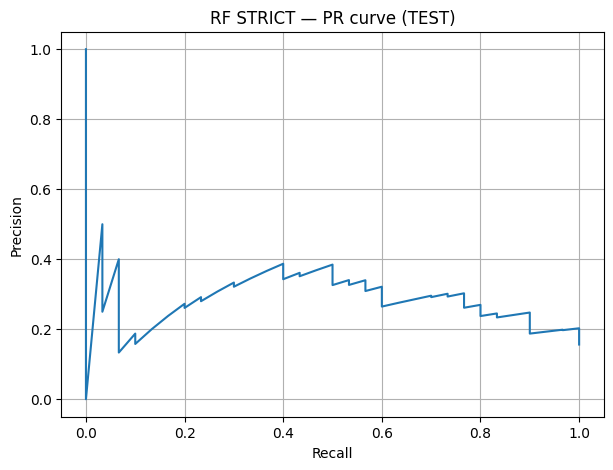


[RF STRICT TEST] ROC-AUC=0.7407 | PR-AUC=0.3001 | F1=0.3830 | thr=0.2599
Confusion:
 [[78 84]
 [ 3 27]]
              precision    recall  f1-score   support

           0      0.963     0.481     0.642       162
           1      0.243     0.900     0.383        30

    accuracy                          0.547       192
   macro avg      0.603     0.691     0.512       192
weighted avg      0.851     0.547     0.602       192

[RF TEST] ROC-AUC=0.7407 | PR-AUC=0.3001

--- Permutation importance (on TEST, raw features) ---
                 feature  importance_mean  importance_std
                 Вид ДТП         0.055692        0.024832
         Значение дороги         0.035024        0.032254
                     dow         0.030126        0.011066
              is_weekend         0.006761        0.009224
                 has_car         0.003984        0.004162
           has_col_other         0.003033        0.001863
             share_old20         0.002701        0.007852
       

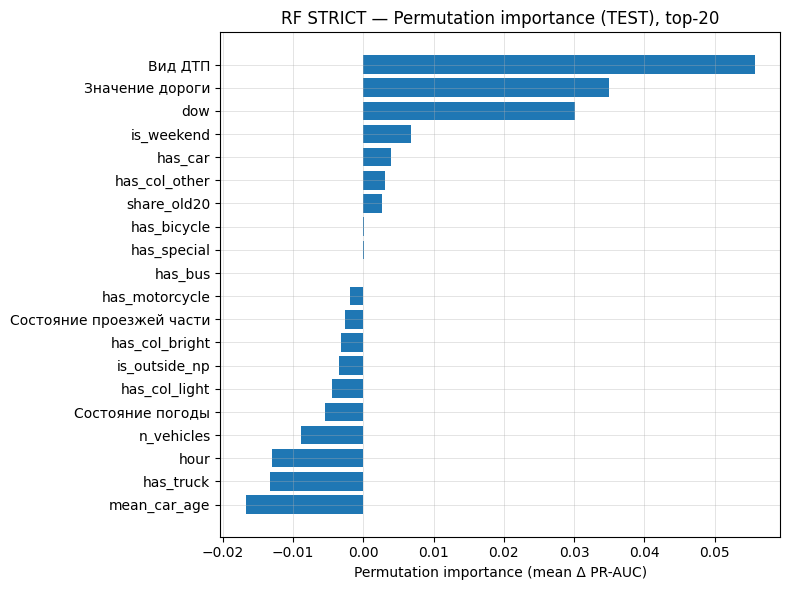


--- PDP/ICE on TEST (2x2): ['hour', 'month', 'dow', 'share_old20'] | kind=both ---


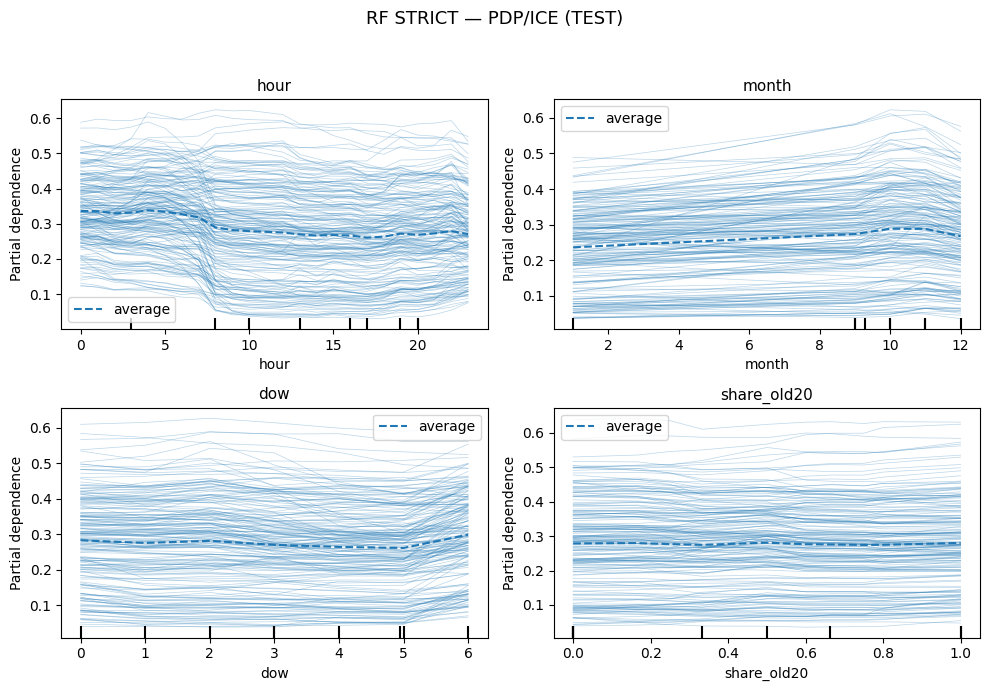


===== RANDOM FOREST EXTENDED =====
VAL best_thr=0.2605 | F1=0.3441 | P=0.2424 | R=0.5926
VAL ROC-AUC=0.6473 | VAL PR-AUC=0.2205


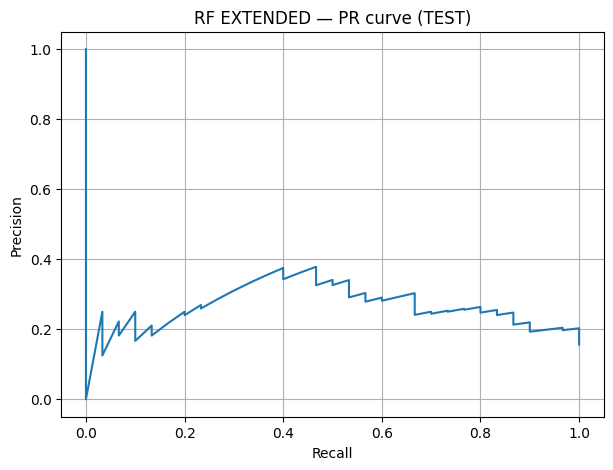


[RF EXTENDED TEST] ROC-AUC=0.7278 | PR-AUC=0.2764 | F1=0.3768 | thr=0.2605
Confusion:
 [[80 82]
 [ 4 26]]
              precision    recall  f1-score   support

           0      0.952     0.494     0.650       162
           1      0.241     0.867     0.377        30

    accuracy                          0.552       192
   macro avg      0.597     0.680     0.514       192
weighted avg      0.841     0.552     0.608       192

[RF TEST] ROC-AUC=0.7278 | PR-AUC=0.2764

--- Permutation importance (on TEST, raw features) ---
                 feature  importance_mean  importance_std
                 Вид ДТП         0.048321        0.019408
         Значение дороги         0.024774        0.027652
                     dow         0.011382        0.012905
              is_weekend         0.002425        0.008187
           has_col_other         0.002150        0.005333
           is_outside_np         0.001588        0.014533
          has_col_bright         0.000667        0.002665
     

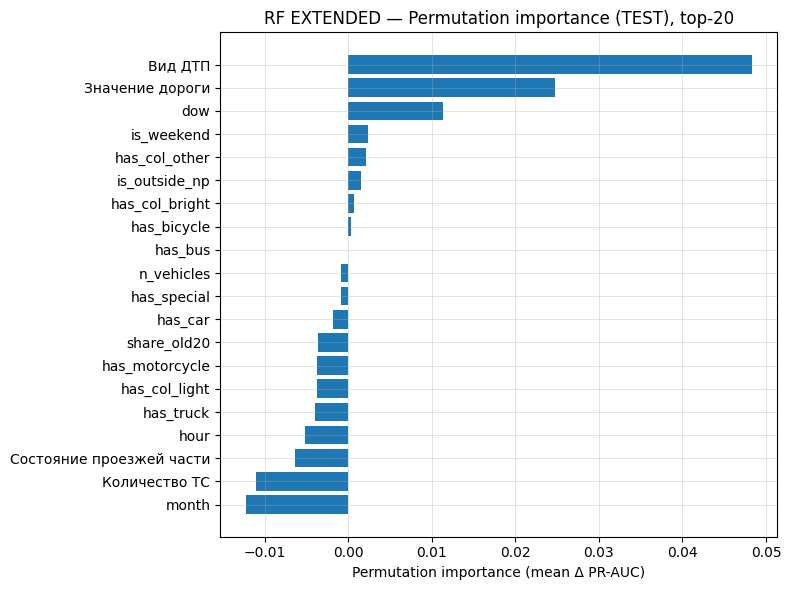


--- PDP/ICE on TEST (2x2): ['hour', 'month', 'dow', 'share_old20'] | kind=both ---


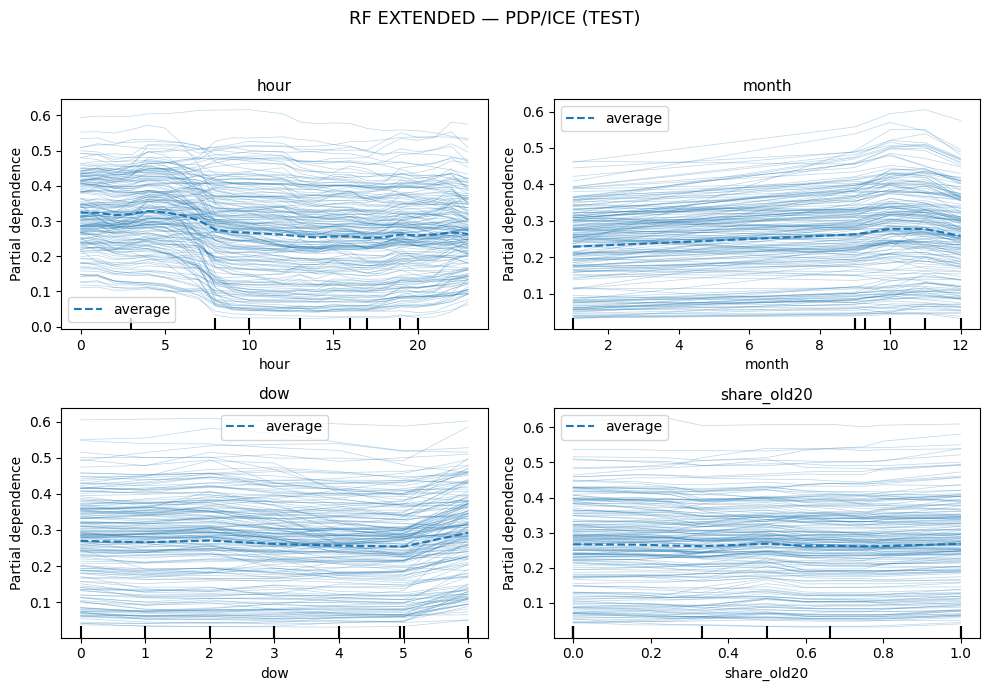

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance, PartialDependenceDisplay
from sklearn.metrics import average_precision_score, roc_auc_score


def run_random_forest_time_split(
    features,
    label,
    n_estimators=800,
    max_depth=None,
    min_samples_leaf=2,
    max_features="sqrt",
    n_jobs=-1,
    perm_repeats=10,
    pdp_features=None,
    pdp_kind=("average", "individual")
):

    X = df[features].copy()
    y = df["fatal"].astype(int)

    X_train = X.loc[train_idx].copy()
    y_train = y.loc[train_idx].copy()

    X_val = X.loc[val_idx].copy()
    y_val = y.loc[val_idx].copy()

    X_test = X.loc[test_idx].copy()
    y_test = y.loc[test_idx].copy()

    numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
    categorical_cols = [c for c in X.columns if c not in numeric_cols]

    pre = ColumnTransformer(
        transformers=[
            ("num", Pipeline([("imp", SimpleImputer(strategy="median"))]), numeric_cols),
            ("cat", Pipeline([
                ("imp", SimpleImputer(strategy="most_frequent")),
                ("ohe", OneHotEncoder(handle_unknown="ignore")),
            ]), categorical_cols),
        ],
        remainder="drop",
        sparse_threshold=0.3
    )

    rf = RandomForestClassifier(
        n_estimators=n_estimators,
        random_state=RANDOM_STATE,
        n_jobs=n_jobs,
        class_weight="balanced_subsample",
        max_depth=max_depth,
        min_samples_leaf=min_samples_leaf,
        max_features=max_features,
        bootstrap=True,
    )

    pipe = Pipeline([("pre", pre), ("clf", rf)])
    pipe.fit(X_train, y_train)

    proba_val = pipe.predict_proba(X_val)[:, 1]
    best_thr, best_f1, best_prec, best_rec = find_best_threshold_f1(y_val.values, proba_val)

    print(f"\n===== RANDOM FOREST {label} =====")
    print(f"VAL best_thr={best_thr:.4f} | F1={best_f1:.4f} | P={best_prec:.4f} | R={best_rec:.4f}")
    print(f"VAL ROC-AUC={roc_auc_score(y_val, proba_val):.4f} | VAL PR-AUC={average_precision_score(y_val, proba_val):.4f}")

    proba_test = pipe.predict_proba(X_test)[:, 1]
    plot_pr_curve(y_test.values, proba_test, title=f"RF {label} — PR curve (TEST)")
    metrics = eval_at_threshold(y_test.values, proba_test, best_thr, label=f"RF {label} TEST")

    metrics["roc_auc"] = float(roc_auc_score(y_test, proba_test))
    metrics["pr_auc"]  = float(average_precision_score(y_test, proba_test))
    print(f"[RF TEST] ROC-AUC={metrics['roc_auc']:.4f} | PR-AUC={metrics['pr_auc']:.4f}")

    print("\n--- Permutation importance (on TEST, raw features) ---")
    perm = permutation_importance(
        pipe, X_test, y_test,
        n_repeats=perm_repeats,
        random_state=RANDOM_STATE,
        scoring="average_precision",
        n_jobs=n_jobs
    )

    perm_imp = pd.DataFrame({
        "feature": X_test.columns,
        "importance_mean": perm.importances_mean,
        "importance_std": perm.importances_std
    }).sort_values("importance_mean", ascending=False)

    print(perm_imp.head(20).to_string(index=False))

    topk = perm_imp.head(20).iloc[::-1]
    plt.figure(figsize=(8, 6))
    plt.barh(topk["feature"], topk["importance_mean"])
    plt.xlabel("Permutation importance (mean Δ PR-AUC)")
    plt.title(f"RF {label} — Permutation importance (TEST), top-20")
    plt.grid(True, linewidth=0.4, alpha=0.6)
    plt.tight_layout()
    plt.show()

    if pdp_features is None:
        candidates = ["hour", "month", "dow", "share_old20"]
        pdp_features = [c for c in candidates if c in X_test.columns and c in features]

    pdp_features = pdp_features[:4]

    if len(pdp_features) > 0:
        kind = "both" if ("average" in pdp_kind and "individual" in pdp_kind) else (
            "individual" if "individual" in pdp_kind else "average"
        )
        print(f"\n--- PDP/ICE on TEST (2x2): {pdp_features} | kind={kind} ---")

        fig, axes = plt.subplots(2, 2, figsize=(10, 7))
        axes = axes.ravel()

        for i, f in enumerate(pdp_features):
            ax = axes[i]
            try:
                PartialDependenceDisplay.from_estimator(
                    pipe,
                    X_test,
                    features=[f],
                    kind=kind,
                    grid_resolution=40,
                    random_state=RANDOM_STATE,
                    ax=ax
                )
                ax.set_title(str(f), fontsize=11)
                ax.tick_params(axis="both", labelsize=9)
                ax.grid(True, linewidth=0.3, alpha=0.5)
            except Exception as e:
                ax.axis("off")
                ax.text(
                    0.5, 0.5,
                    f"FAIL:\n{f}\n{type(e).__name__}",
                    ha="center", va="center", fontsize=9
                )

        for j in range(len(pdp_features), 4):
            axes[j].axis("off")

        fig.suptitle(f"RF {label} — PDP/ICE (TEST)", fontsize=13, y=0.98)
        fig.tight_layout(rect=[0, 0, 1, 0.95])
        plt.show()
    else:
        print("\n--- PDP/ICE skipped: no suitable features found ---")

    return {
        "pipe": pipe,
        "metrics": metrics,
        "best_thr": best_thr,
        "perm_importance": perm_imp
    }


rf_strict_out = run_random_forest_time_split(
    strict_features,
    label="STRICT",
    n_estimators=800,
    max_depth=None,
    min_samples_leaf=2,
    max_features="sqrt",
    perm_repeats=10,
    pdp_features=None,
    pdp_kind=("average", "individual"),
)

rf_ext_out = run_random_forest_time_split(
    extended_features,
    label="EXTENDED",
    n_estimators=800,
    max_depth=None,
    min_samples_leaf=2,
    max_features="sqrt",
    perm_repeats=10,
    pdp_features=None,
    pdp_kind=("average", "individual"),
)